# Credit Default Prediction with Reject Inference

## Author: Sohom Halder | MS Statistics 
#### Dataset: LendingClub Loan Data 2007–2018
**Tools: Python · pandas · scikit-learn · matplotlib · seaborn · Streamlit**

---

**Project Overview:**

This notebook develops a production-grade credit scorecard using over 1.3 million loan records from the LendingClub platform. The pipeline follows the industry-standard Basel II scorecard development process — from raw data ingestion through Weight of Evidence (WoE) feature transformation, logistic regression modelling, FICO-style score scaling, and three reject inference methodologies to correct for sample selection bias.

---

## Phase 1 — Data Foundation And Exploratory Data Analysis

Sourcing the raw LendingClub accepted and rejected loan files — happens outside this notebook. Everything from here on is executed and validated inline, starting with the plotting conventions, colour palette, and file paths used throughout the rest of the project.


In [1]:
# Cell 1 — Data Foundation And Exploratory Data Analysis
# Credit Scorecard with Reject Inference | LendingClub 2007–2018

import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

warnings.filterwarnings('ignore')

# ── Professional plotting style ──────────────────────────────
plt.rcParams.update({
    'figure.dpi'        : 120,
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : 'white',
    'axes.grid'         : True,
    'grid.alpha'        : 0.3,
    'grid.linestyle'    : '--',
    'font.family'       : 'DejaVu Sans',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 10,
    'ytick.labelsize'   : 10,
})

COLORS = {
    'good'     : '#2ecc71',   # green  → performing / fully paid
    'bad'      : '#e74c3c',   # red    → default / charged off
    'neutral'  : '#3498db',   # blue   → general
    'rejected' : '#95a5a6',   # grey   → rejected applicants
    'highlight': '#f39c12',   # amber  → key callout
}

# Define file paths
ACCEPTED_PATH = "accepted_2007_to_2018Q4.csv"
REJECTED_PATH = "rejected_2007_to_2018Q4.csv"

print("=" * 55)
print("Phase 1: Data Foundation And Exploratory Data Analysis")
print("=" * 55) 
print(f"\n  pandas  version : {pd.__version__}")
print(f"  numpy   version : {np.__version__}")
print(f"  seaborn version : {sns.__version__}")
print(f"  matplotlib      : {plt.matplotlib.__version__}")
print("\n Environment ready. Proceeding to data load.\n")

Phase 1: Data Foundation And Exploratory Data Analysis

  pandas  version : 3.0.3
  numpy   version : 2.4.6
  seaborn version : 0.13.2
  matplotlib      : 3.10.9

 Environment ready. Proceeding to data load.



### Building the modelling population

Loans still `Current` or in a grace period don't have a definitive outcome yet, so the modelling population is restricted to loans that reached a final status: `Fully Paid` or `Charged Off`. The binary target `default_flag` is defined directly from this filter, and the resulting portfolio-level default rate becomes the baseline every later model is measured against.


In [2]:
# ============================================================
# Cell 2 - Data Loading and Modelling Population Setup
# ============================================================

# Load Datasets (low_memory=False handles mixed dtype warnings)
acc = pd.read_csv(ACCEPTED_PATH, low_memory=False)
rej = pd.read_csv(REJECTED_PATH, low_memory=False)

# Clean column names
acc.columns = acc.columns.str.strip()
rej.columns = rej.columns.str.strip()

# Build Modelling Population
# Filter out current/grace-period loans to ensure definitive performance outcomes
keep_statuses = ['Fully Paid', 'Charged Off']
acc_clean = acc[acc['loan_status'].isin(keep_statuses)].copy()

# Create binary target variable (1 = Default/Charged Off, 0 = Good/Fully Paid)
acc_clean['default_flag'] = (acc_clean['loan_status'] == 'Charged Off').astype(int)
acc_clean['issue_year'] = pd.to_datetime(acc_clean['issue_d'], format='%b-%Y', errors='coerce').dt.year

# Calculate Portfolio Baseline
total = len(acc_clean)
n_default = acc_clean['default_flag'].sum()
n_good = total - n_default
default_rt = (n_default / total) * 100

print(f"Modelling Population Ready:")
print(f"Total Observations: {total:,.0f}")
print(f"Good Loans (Fully Paid): {n_good:,.0f} ({100 - default_rt:.1f}%)")
print(f"Bad Loans (Charged Off): {n_default:,.0f} ({default_rt:.1f}%)")

Modelling Population Ready:
Total Observations: 1,345,310
Good Loans (Fully Paid): 1,076,751 (80.0%)
Bad Loans (Charged Off): 268,559 (20.0%)


### Default rate by grade and vintage

LendingClub's own letter grade is the bank's existing risk assessment, so checking that default rate rises monotonically from Grade A to Grade G is really a sanity check on the data — and a benchmark. Any model built later in this notebook needs to beat, not just replicate, what the grade already captures. The companion vintage view (default rate by issue year) exists to flag which cohorts are mature enough to trust: recent years understate risk simply because those loans haven't had time to default, which is exactly the concern the train/test split addresses in Phase 3.


  DEFAULT RATE BY GRADE — Core portfolio segmentation
  Grade        Volume   Defaults   Default%  Avg Rate%  Avg Loan$
  ------------------------------------------------------------
  A           235,090     14,201       6.0%       7.1%    13,892
  B           392,741     52,569      13.4%      10.7%    13,238
  C           381,686     85,649      22.4%      14.0%    14,188
  D           200,953     61,054      30.4%      17.7%    15,272
  E            93,650     36,035      38.5%      21.1%    17,618
  F            32,058     14,491      45.2%      24.9%    19,088
  G             9,132      4,560      49.9%      27.7%    20,589

  VINTAGE ANALYSIS — Default rate by issue year
  (Recent years show lower rate — loans not yet matured)
  Year         Volume   Defaults   Default%
  ------------------------------------------
  2007          251.0       45.0      17.9%
  2008        1,562.0      247.0      15.8%
  2009        4,716.0      594.0      12.6%
  2010       11,536.0    1,487.0   

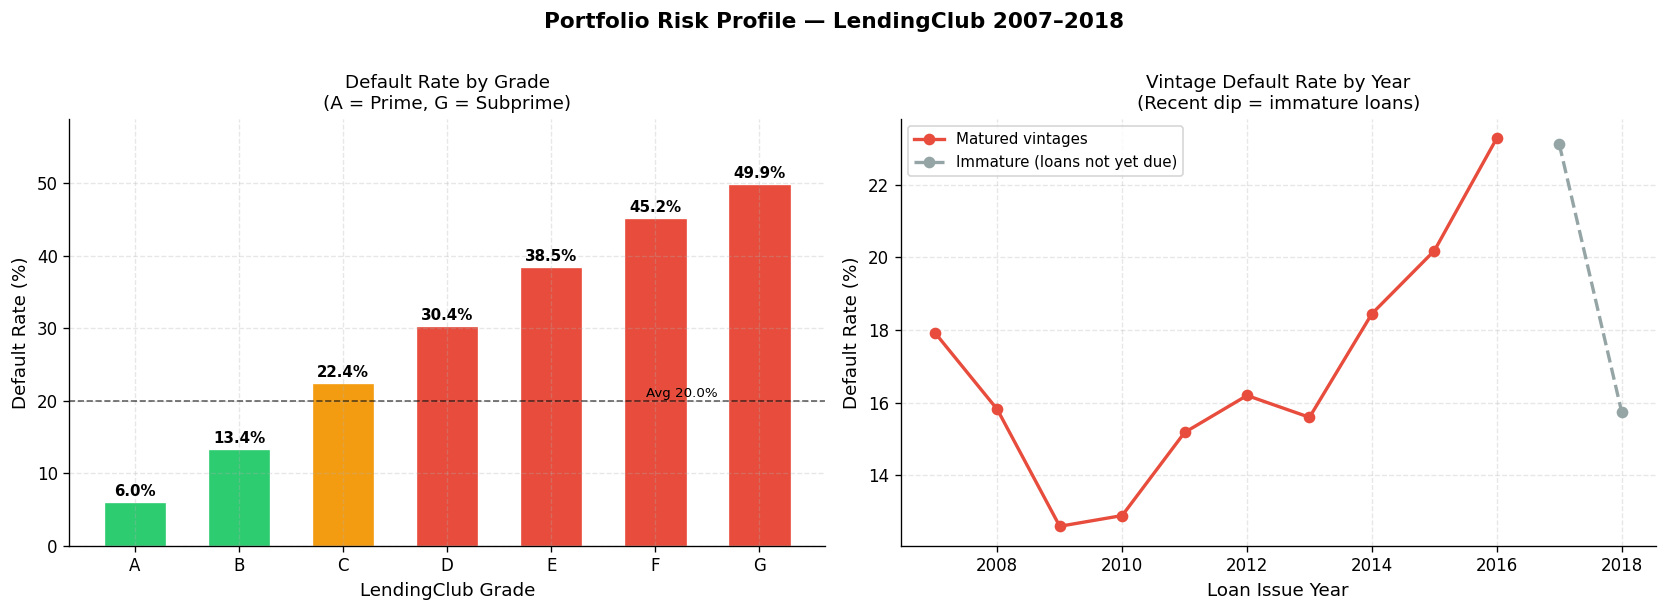


Plot saved:  eda_grade_vintage.png

KEY BUSINESS INSIGHT:
   Grade G default rate should be ~4-5x Grade A.
   If it is, LendingClub's grading is monotonically
   consistent — our model must BEAT this benchmark.


In [3]:
# ============================================================
# CELL 3 — Default rate by grade + vintage analysis
# Banking insight: Grade is the bank's OWN risk assessment.
# If our model can't beat grade-level discrimination,
# it adds no value. This is our performance benchmark.
# ============================================================

# ── 3a: Default rate by grade ────────────────────────────────
grade_stats = (
    acc_clean
    .groupby('grade')
    .agg(
        total        = ('default_flag', 'count'),
        defaults     = ('default_flag', 'sum'),
        avg_int_rate = ('int_rate', 'mean'),
        avg_loan_amt = ('loan_amnt', 'mean'),
    )
    .assign(default_rate = lambda x: x['defaults'] / x['total'] * 100)
    .reset_index()
)

print("=" * 65)
print("  DEFAULT RATE BY GRADE — Core portfolio segmentation")
print("=" * 65)
print(f"  {'Grade':<8} {'Volume':>10} {'Defaults':>10} "
      f"{'Default%':>10} {'Avg Rate%':>10} {'Avg Loan$':>10}")
print("  " + "-" * 60)
for _, row in grade_stats.iterrows():
    print(f"  {row['grade']:<8} {row['total']:>10,} {row['defaults']:>10,} "
          f"{row['default_rate']:>9.1f}% {row['avg_int_rate']:>9.1f}% "
          f"{row['avg_loan_amt']:>9,.0f}")

# ── 3b: Vintage analysis — default rate by issue year ────────
acc_clean['issue_year'] = (
    pd.to_datetime(acc_clean['issue_d'], format='%b-%Y', errors='coerce')
    .dt.year
)

vintage = (
    acc_clean
    .groupby('issue_year')
    .agg(
        total       = ('default_flag', 'count'),
        defaults    = ('default_flag', 'sum'),
    )
    .assign(default_rate = lambda x: x['defaults'] / x['total'] * 100)
    .reset_index()
    .dropna(subset=['issue_year'])
)

print()
print("=" * 55)
print("  VINTAGE ANALYSIS — Default rate by issue year")
print("  (Recent years show lower rate — loans not yet matured)")
print("=" * 55)
print(f"  {'Year':<8} {'Volume':>10} {'Defaults':>10} {'Default%':>10}")
print("  " + "-" * 42)
for _, row in vintage.iterrows():
    year = int(row['issue_year'])
    flag = " ← immature" if year >= 2017 else ""
    print(f"  {year:<8} {row['total']:>10,} {row['defaults']:>10,} "
          f"{row['default_rate']:>9.1f}%{flag}")

# ── Plot: 2-panel figure ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Portfolio Risk Profile — LendingClub 2007–2018',
             fontsize=13, fontweight='bold', y=1.01)

# Panel 1 — Default rate by grade (bar)
ax1 = axes[0]
bars = ax1.bar(
    grade_stats['grade'],
    grade_stats['default_rate'],
    color=[COLORS['good'] if r < 15 else
           COLORS['highlight'] if r < 25 else
           COLORS['bad']
           for r in grade_stats['default_rate']],
    edgecolor='white', linewidth=0.8, width=0.6
)
# Annotate bars
for bar, rate in zip(bars, grade_stats['default_rate']):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.4,
             f'{rate:.1f}%', ha='center', va='bottom',
             fontsize=9, fontweight='bold')

ax1.set_xlabel('LendingClub Grade', fontsize=11)
ax1.set_ylabel('Default Rate (%)', fontsize=11)
ax1.set_title('Default Rate by Grade\n(A = Prime, G = Subprime)',
              fontsize=11)
ax1.set_ylim(0, grade_stats['default_rate'].max() * 1.18)

# Add overall average line
avg_default = acc_clean['default_flag'].mean() * 100
ax1.axhline(avg_default, color='black', linestyle='--',
            linewidth=1, alpha=0.6)
ax1.text(5.6, avg_default + 0.5, f'Avg {avg_default:.1f}%',
         fontsize=8, ha='right')

# Panel 2 — Vintage default rate (line)
ax2 = axes[1]
mature   = vintage[vintage['issue_year'] < 2017]
immature = vintage[vintage['issue_year'] >= 2017]

ax2.plot(mature['issue_year'], mature['default_rate'],
         color=COLORS['bad'], marker='o', linewidth=2,
         markersize=6, label='Matured vintages')
ax2.plot(immature['issue_year'], immature['default_rate'],
         color=COLORS['rejected'], marker='o', linewidth=2,
         linestyle='--', markersize=6, label='Immature (loans not yet due)')

ax2.set_xlabel('Loan Issue Year', fontsize=11)
ax2.set_ylabel('Default Rate (%)', fontsize=11)
ax2.set_title('Vintage Default Rate by Year\n(Recent dip = immature loans)',
              fontsize=11)
ax2.legend(fontsize=9)
ax2.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig('eda_grade_vintage.png', dpi=120,
            bbox_inches='tight')
plt.show()
print("\nPlot saved:  eda_grade_vintage.png")
print("\nKEY BUSINESS INSIGHT:")
print("   Grade G default rate should be ~4-5x Grade A.")
print("   If it is, LendingClub's grading is monotonically")
print("   consistent — our model must BEAT this benchmark.")

### Univariate risk drivers: purpose, employment length, state

Before any binning or modelling, it's worth checking — visually and numerically — whether application-time fields discriminate between good and bad loans at all. Loan purpose, employment length, and state are checked individually here; employment length in particular is the raw material for the Employment Stability Score engineered in Phase 3.


  DEFAULT RATE BY LOAN PURPOSE
  Purpose                            Volume   Default%
  ----------------------------------------------------
  small_business                     15,416      29.7%  ██████████████
  renewable_energy                      933      23.7%  ███████████
  moving                              9,480      23.4%  ███████████
  house                               7,253      21.9%  ██████████
  medical                            15,554      21.8%  ██████████
  debt_consolidation                780,321      21.1%  ██████████
  other                              77,875      21.0%  ██████████
  vacation                            9,065      19.2%  █████████
  major_purchase                     29,425      18.6%  █████████
  home_improvement                   87,504      17.7%  ████████
  educational                           326      17.2%  ████████
  credit_card                       295,279      16.9%  ████████
  car                                14,585      14.7%  █

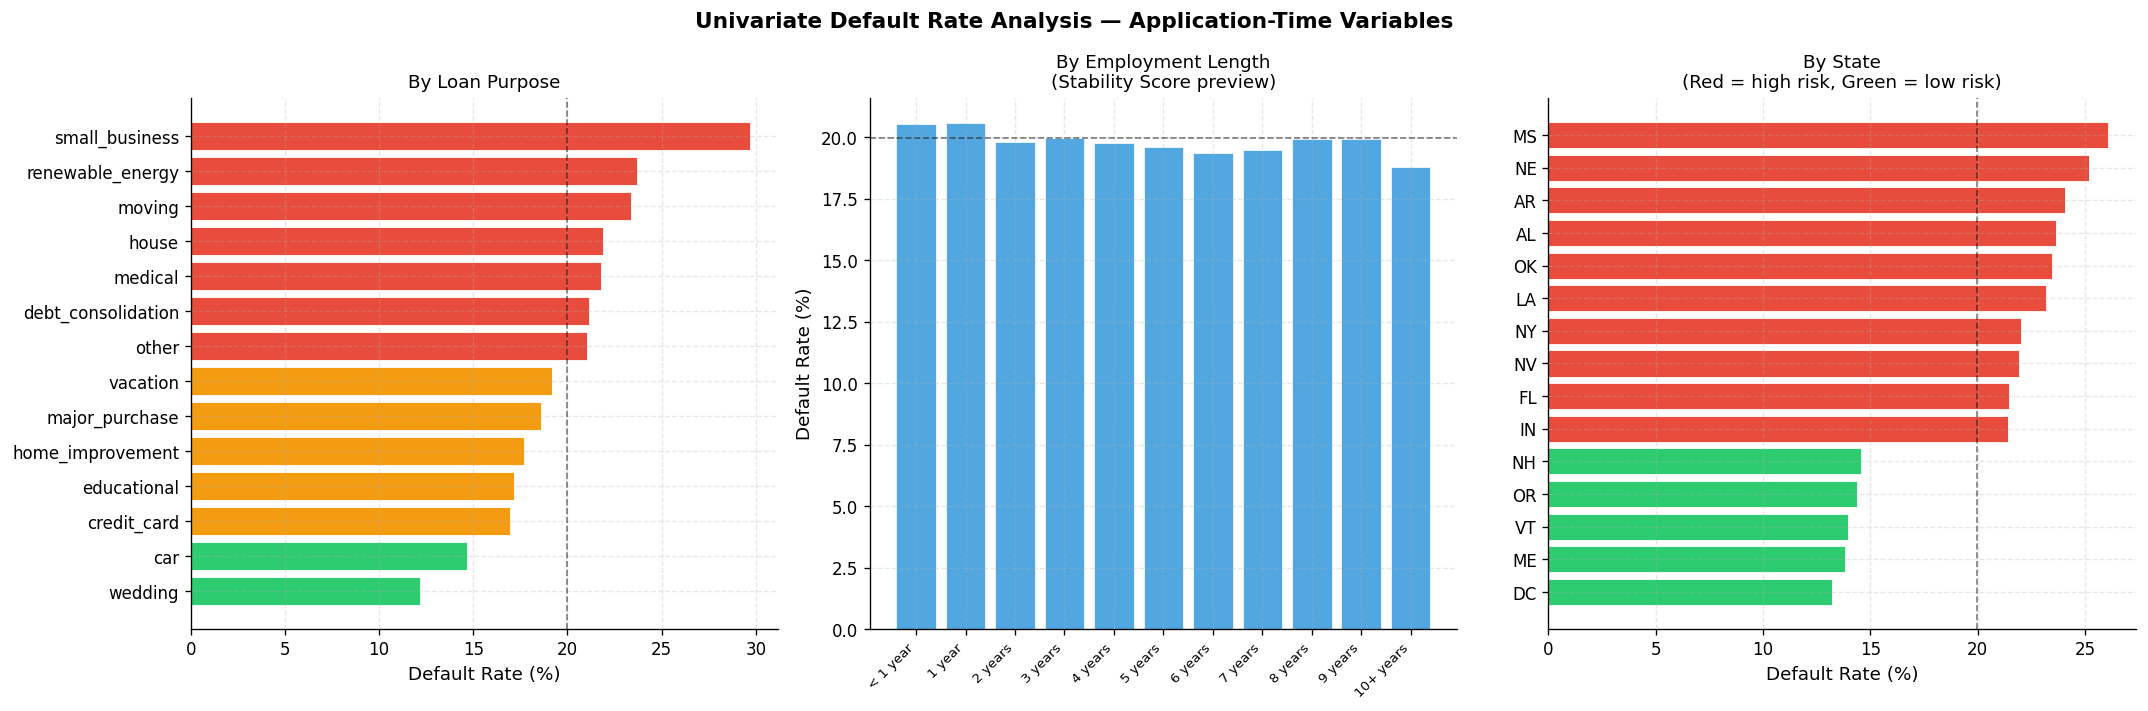


Plot saved: eda_purpose_state_emp.png

NOTE FOR PHASE 2:
   Purpose and emp_length will both get WoE binning.
   State may be grouped into regions to avoid sparse bins.


In [4]:
# ============================================================
# CELL 4 — Default rate by purpose, state, employment length
# Banking rationale: these are application-time variables.
# We're checking if they discriminate between good/bad loans
# BEFORE we even build a model — this is univariate analysis,
# the precursor to Information Value (IV) in Phase 2.
# ============================================================

# ── 4a: Default rate by loan purpose ─────────────────────────
purpose_stats = (
    acc_clean
    .groupby('purpose')
    .agg(total=('default_flag','count'),
         defaults=('default_flag','sum'))
    .assign(default_rate=lambda x: x['defaults']/x['total']*100)
    .sort_values('default_rate', ascending=False)
    .reset_index()
)

print("=" * 65)
print("  DEFAULT RATE BY LOAN PURPOSE")
print("=" * 65)
print(f"  {'Purpose':<30} {'Volume':>10} {'Default%':>10}")
print("  " + "-" * 52)
for _, row in purpose_stats.iterrows():
    bar = '█' * int(row['default_rate'] / 2)
    print(f"  {row['purpose']:<30} {row['total']:>10,} "
          f"{row['default_rate']:>9.1f}%  {bar}")

# ── 4b: Default rate by employment length ────────────────────
emp_stats = (
    acc_clean
    .groupby('emp_length')
    .agg(total=('default_flag','count'),
         defaults=('default_flag','sum'))
    .assign(default_rate=lambda x: x['defaults']/x['total']*100)
    .reset_index()
)

# Define logical sort order for employment length
emp_order = ['< 1 year','1 year','2 years','3 years','4 years',
             '5 years','6 years','7 years','8 years','9 years',
             '10+ years','n/a']
emp_stats['sort_key'] = emp_stats['emp_length'].map(
    {v: i for i, v in enumerate(emp_order)}
)
emp_stats = emp_stats.sort_values('sort_key').dropna(subset=['sort_key'])

print()
print("=" * 60)
print("  DEFAULT RATE BY EMPLOYMENT LENGTH")
print("  (Will become Employment Stability Score in Phase 2)")
print("=" * 60)
print(f"  {'Emp Length':<14} {'Volume':>10} {'Default%':>10}")
print("  " + "-" * 36)
for _, row in emp_stats.iterrows():
    print(f"  {row['emp_length']:<14} {row['total']:>10,} "
          f"{row['default_rate']:>9.1f}%")

# ── 4c: Top 10 states by default rate (min 1000 loans) ──────
state_stats = (
    acc_clean
    .groupby('addr_state')
    .agg(total=('default_flag','count'),
         defaults=('default_flag','sum'))
    .assign(default_rate=lambda x: x['defaults']/x['total']*100)
    .query('total >= 1000')
    .sort_values('default_rate', ascending=False)
    .reset_index()
)

print()
print("=" * 55)
print("  DEFAULT RATE BY STATE (min 1,000 loans)")
print("  Top 10 highest + Top 5 lowest")
print("=" * 55)
print(f"  {'State':<8} {'Volume':>10} {'Default%':>10}")
print("  " + "─" * 32)
print("  --- Highest default states ---")
for _, row in state_stats.head(10).iterrows():
    print(f"  {row['addr_state']:<8} {row['total']:>10,} "
          f"{row['default_rate']:>9.1f}%")
print("  --- Lowest default states ---")
for _, row in state_stats.tail(5).iterrows():
    print(f"  {row['addr_state']:<8} {row['total']:>10,} "
          f"{row['default_rate']:>9.1f}%")

# ── Plot: 3-panel figure ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Univariate Default Rate Analysis — Application-Time Variables',
             fontsize=13, fontweight='bold')

# Panel 1: Purpose (horizontal bar)
ax1 = axes[0]
colors_p = [COLORS['bad'] if r > 20 else
            COLORS['highlight'] if r > 15 else
            COLORS['good']
            for r in purpose_stats['default_rate']]
ax1.barh(purpose_stats['purpose'], purpose_stats['default_rate'],
         color=colors_p, edgecolor='white', linewidth=0.5)
ax1.axvline(acc_clean['default_flag'].mean()*100,
            color='black', linestyle='--', linewidth=1, alpha=0.5)
ax1.set_xlabel('Default Rate (%)')
ax1.set_title('By Loan Purpose', fontsize=11)
ax1.invert_yaxis()

# Panel 2: Employment length (bar)
ax2 = axes[1]
ax2.bar(range(len(emp_stats)), emp_stats['default_rate'],
        color=COLORS['neutral'], edgecolor='white', linewidth=0.5,
        alpha=0.85)
ax2.set_xticks(range(len(emp_stats)))
ax2.set_xticklabels(emp_stats['emp_length'], rotation=45, ha='right',
                    fontsize=8)
ax2.axhline(acc_clean['default_flag'].mean()*100,
            color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_ylabel('Default Rate (%)')
ax2.set_title('By Employment Length\n(Stability Score preview)', fontsize=11)

# Panel 3: Top/bottom states
ax3 = axes[2]
top_states    = state_stats.head(10)
bottom_states = state_stats.tail(5)
plot_states   = pd.concat([top_states, bottom_states])
bar_colors    = ([COLORS['bad']] * 10 + [COLORS['good']] * 5)
ax3.barh(plot_states['addr_state'], plot_states['default_rate'],
         color=bar_colors, edgecolor='white', linewidth=0.5)
ax3.axvline(acc_clean['default_flag'].mean()*100,
            color='black', linestyle='--', linewidth=1, alpha=0.5)
ax3.set_xlabel('Default Rate (%)')
ax3.set_title('By State\n(Red = high risk, Green = low risk)', fontsize=11)
ax3.invert_yaxis()

plt.tight_layout()
plt.savefig('eda_purpose_state_emp.png', dpi=120,
            bbox_inches='tight')
plt.show()
print("\nPlot saved: eda_purpose_state_emp.png")
print()
print("NOTE FOR PHASE 2:")
print("   Purpose and emp_length will both get WoE binning.")
print("   State may be grouped into regions to avoid sparse bins.")

### Missing value analysis

In application data, a blank field is rarely random — someone who leaves income blank is a different applicant from someone who reports it. This cell quantifies missingness across the full accepted-loan table, then zooms into the ~20 candidate features for the model specifically, applying a simple decision rule: drop columns above 80% missing, add a missing-indicator dummy between 10–80%, and impute quietly below that. The heatmap (on a 5,000-row sample, since the full 1.3M rows would be unreadable and slow to render) makes the pattern of missingness visible rather than just tabular.



  MISSING VALUES — ACCEPTED LOANS (modelling population)
  Total rows: 1,345,310  |  Columns with nulls: 105
  Column                                 Missing     Pct%
  -------------------------------------------------------
  member_id                           1,345,310.0   100.0%  ← DROP (>80% missing)
  next_pymnt_d                        1,345,310.0   100.0%  ← DROP (>80% missing)
  orig_projected_additional_accrued_interest 1,341,551.0    99.7%  ← DROP (>80% missing)
  hardship_type                       1,339,556.0    99.6%  ← DROP (>80% missing)
  hardship_reason                     1,339,556.0    99.6%  ← DROP (>80% missing)
  hardship_status                     1,339,556.0    99.6%  ← DROP (>80% missing)
  deferral_term                       1,339,556.0    99.6%  ← DROP (>80% missing)
  hardship_amount                     1,339,556.0    99.6%  ← DROP (>80% missing)
  hardship_start_date                 1,339,556.0    99.6%  ← DROP (>80% missing)
  hardship_end_date          

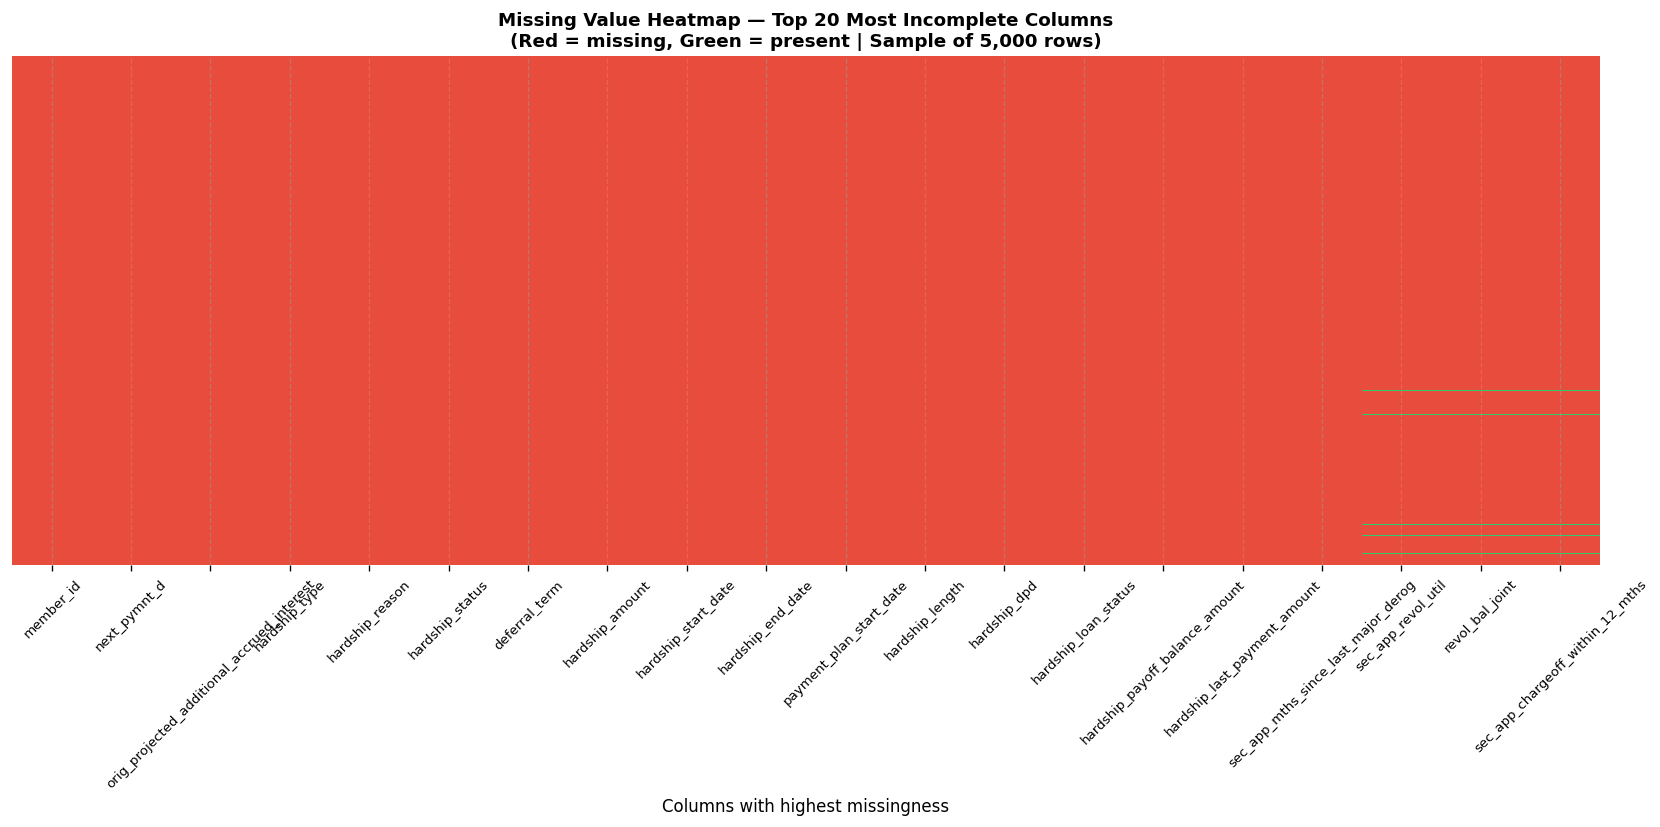


Plot saved:  eda_missing_heatmap.png

KEY DECISION POINT:
   Columns with >80% missing → DROP in Phase 2
   Columns with 10–80% missing in key vars → missing
   indicator dummy variable (miss_varname = 1/0)
   This is standard Basel II scorecard practice.


In [5]:
# ============================================================
# CELL 5 — Missing value analysis
# Banking rationale: in a production scorecard, missing data
# is NOT random. A borrower who leaves income blank is
# statistically different from one who fills it in.
# Missing = its own information signal.
# ============================================================

# ── 5a: Missing value summary for accepted loans ─────────────
def missing_summary(df, label):
    total = len(df)
    miss  = df.isnull().sum()
    miss  = miss[miss > 0].sort_values(ascending=False)
    pct   = (miss / total * 100).round(2)
    result = pd.DataFrame({
        'missing_count' : miss,
        'missing_pct'   : pct
    })
    print(f"\n{'='*60}")
    print(f"  MISSING VALUES — {label}")
    print(f"  Total rows: {total:,}  |  Columns with nulls: {len(result)}")
    print(f"{'='*60}")
    print(f"  {'Column':<35} {'Missing':>10} {'Pct%':>8}")
    print(f"  {'-'*55}")
    for col, row in result.head(30).iterrows():
        flag = ''
        if row['missing_pct'] > 80:
            flag = '  ← DROP (>80% missing)'
        elif row['missing_pct'] > 40:
            flag = '  ← HIGH missingness'
        elif row['missing_pct'] > 10:
            flag = '  ← impute carefully'
        print(f"  {col:<35} {row['missing_count']:>10,} "
              f"{row['missing_pct']:>7.1f}%{flag}")
    return result

acc_missing = missing_summary(acc_clean, "ACCEPTED LOANS (modelling population)")

# ── 5b: Check our key application-time variables specifically ─
key_vars = [
    'loan_amnt', 'term', 'int_rate', 'installment',
    'grade', 'sub_grade', 'emp_length', 'home_ownership',
    'annual_inc', 'verification_status', 'purpose',
    'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high',
    'open_acc', 'pub_rec', 'revol_bal', 'revol_util',
    'total_acc', 'addr_state', 'earliest_cr_line'
]

print()
print("=" * 60)
print("  KEY APPLICATION-TIME VARIABLES — Missingness check")
print("  These are the ~20 variables we will use in the model")
print("=" * 60)
print(f"  {'Variable':<25} {'Missing':>10} {'Pct%':>8}  {'Status'}")
print(f"  {'-'*65}")

for col in key_vars:
    if col in acc_clean.columns:
        n_miss = acc_clean[col].isnull().sum()
        pct    = n_miss / len(acc_clean) * 100
        if pct == 0:
            status = 'Complete'
        elif pct < 1:
            status = 'Minimal — median/mode impute'
        elif pct < 5:
            status = 'Low — impute'
        elif pct < 20:
            status = 'Moderate — impute + missing flag'
        else:
            status = 'HIGH — missing indicator variable'
        print(f"  {col:<25} {n_miss:>10,} {pct:>7.1f}%  {status}")
    else:
        print(f"  {col:<25} {'NOT FOUND':>19}")

# ── 5c: Missing value heatmap (top 20 most missing columns) ──
top_missing_cols = acc_missing.head(20).index.tolist()

# Sample 5000 rows for heatmap (full 1.3M is too slow to render)
sample_idx = acc_clean[top_missing_cols].sample(
    n=min(5000, len(acc_clean)), random_state=42
)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    sample_idx.isnull(),
    cbar=False,
    yticklabels=False,
    cmap=['#2ecc71', '#e74c3c'],   # green=present, red=missing
    ax=ax
)
ax.set_title(
    'Missing Value Heatmap — Top 20 Most Incomplete Columns\n'
    '(Red = missing, Green = present | Sample of 5,000 rows)',
    fontsize=11, fontweight='bold'
)
ax.set_xlabel('Columns with highest missingness', fontsize=10)
ax.tick_params(axis='x', rotation=45, labelsize=8)

plt.tight_layout()
plt.savefig('eda_missing_heatmap.png', dpi=120,
            bbox_inches='tight')
plt.show()

print("\nPlot saved:  eda_missing_heatmap.png")
print()
print("KEY DECISION POINT:")
print("   Columns with >80% missing → DROP in Phase 2")
print("   Columns with 10–80% missing in key vars → missing")
print("   indicator dummy variable (miss_varname = 1/0)")
print("   This is standard Basel II scorecard practice.")

### Distribution comparisons and class balance

Closing out the EDA phase: loan amount, interest rate, DTI, FICO, and income are compared across good and bad borrowers to see which distributions actually separate, and the good/bad split is checked directly. At roughly 80/20, the class imbalance here is mild enough that resampling isn't necessary — WoE-based logistic regression handles this ratio without it.


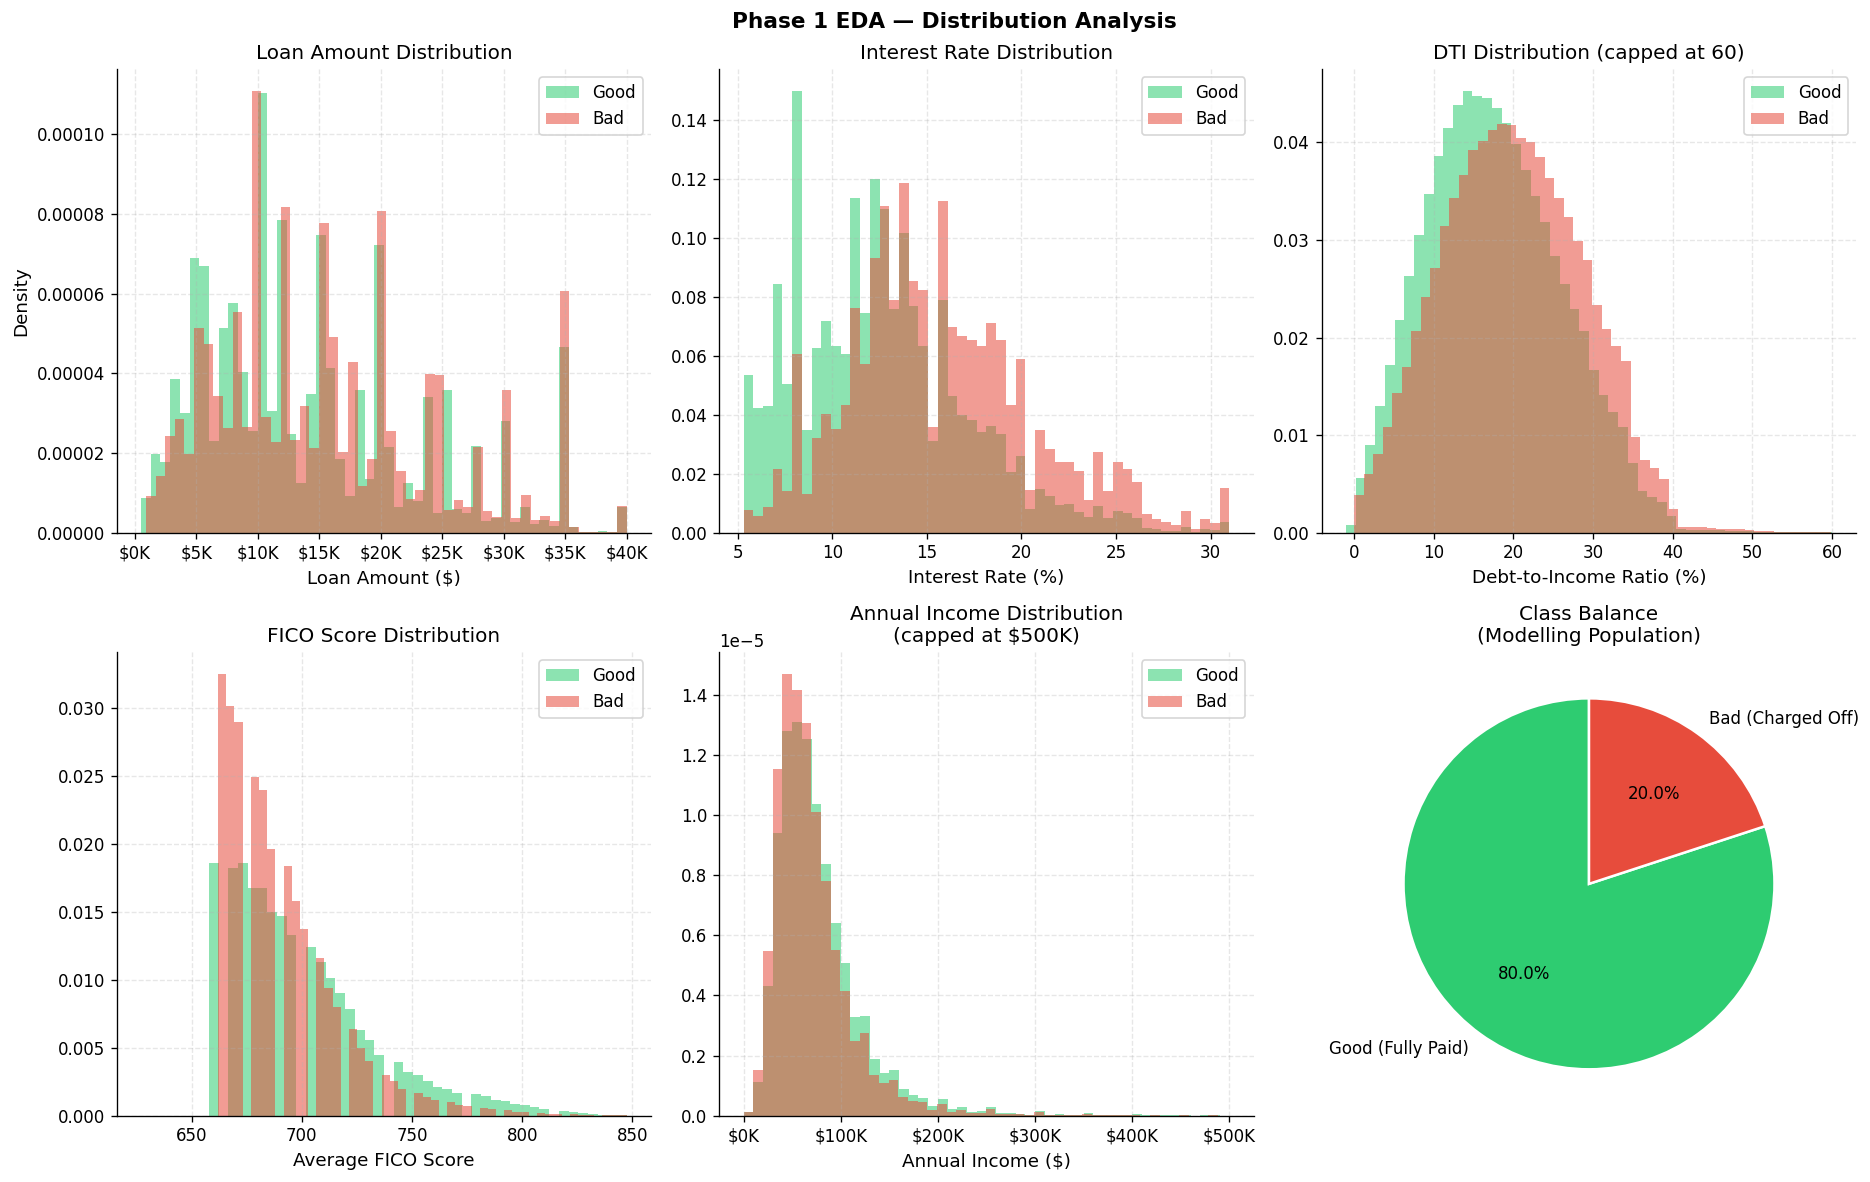

  DISTRIBUTION SUMMARY — Good vs Bad borrowers

  Loan Amount ($)
    Good — mean:   14,134.4  median:   12,000.0
    Bad  — mean:   15,565.1  median:   14,350.0
    Bad borrowers have 10.1% higher mean

  Interest Rate (%)
    Good — mean:       12.6  median:       12.2
    Bad  — mean:       15.7  median:       15.1
    Bad borrowers have 24.5% higher mean

  DTI (%)
    Good — mean:       17.8  median:       17.1
    Bad  — mean:       20.2  median:       19.8
    Bad borrowers have 13.2% higher mean

  FICO Score
    Good — mean:      700.3  median:      692.0
    Bad  — mean:      689.9  median:      682.0
    Bad borrowers have 1.5% lower mean

  Annual Income ($)
    Good — mean:   77,705.9  median:   65,000.0
    Bad  — mean:   70,400.7  median:   60,000.0
    Bad borrowers have 9.4% lower mean

Phase 1 EDA complete.


In [6]:
# ============================================================
# CELL 6 — Distribution plots + class imbalance
# Final EDA cell — closes Phase 1
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Phase 1 EDA — Distribution Analysis',
             fontsize=13, fontweight='bold')

# ── 6a: Loan amount by default status ───────────────────────
ax = axes[0, 0]
for flag, label, color in [(0,'Good','#2ecc71'), (1,'Bad','#e74c3c')]:
    subset = acc_clean[acc_clean['default_flag'] == flag]['loan_amnt']
    ax.hist(subset, bins=50, alpha=0.55, color=color,
            label=label, density=True)
ax.set_title('Loan Amount Distribution')
ax.set_xlabel('Loan Amount ($)')
ax.set_ylabel('Density')
ax.legend()
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# ── 6b: Interest rate by default status ─────────────────────
ax = axes[0, 1]
for flag, label, color in [(0,'Good','#2ecc71'), (1,'Bad','#e74c3c')]:
    subset = acc_clean[acc_clean['default_flag'] == flag]['int_rate']
    ax.hist(subset, bins=50, alpha=0.55, color=color,
            label=label, density=True)
ax.set_title('Interest Rate Distribution')
ax.set_xlabel('Interest Rate (%)')
ax.legend()

# ── 6c: DTI by default status ───────────────────────────────
ax = axes[0, 2]
dti_clean = acc_clean[acc_clean['dti'] < 60]   # cap extreme outliers
for flag, label, color in [(0,'Good','#2ecc71'), (1,'Bad','#e74c3c')]:
    subset = dti_clean[dti_clean['default_flag'] == flag]['dti']
    ax.hist(subset, bins=50, alpha=0.55, color=color,
            label=label, density=True)
ax.set_title('DTI Distribution (capped at 60)')
ax.set_xlabel('Debt-to-Income Ratio (%)')
ax.legend()

# ── 6d: FICO score by default status ────────────────────────
ax = axes[1, 0]
acc_clean['fico_avg'] = (acc_clean['fico_range_low'] +
                          acc_clean['fico_range_high']) / 2
for flag, label, color in [(0,'Good','#2ecc71'), (1,'Bad','#e74c3c')]:
    subset = acc_clean[acc_clean['default_flag'] == flag]['fico_avg']
    ax.hist(subset, bins=50, alpha=0.55, color=color,
            label=label, density=True)
ax.set_title('FICO Score Distribution')
ax.set_xlabel('Average FICO Score')
ax.legend()

# ── 6e: Annual income (log scale) ───────────────────────────
ax = axes[1, 1]
inc_clean = acc_clean[acc_clean['annual_inc'] < 500000]
for flag, label, color in [(0,'Good','#2ecc71'), (1,'Bad','#e74c3c')]:
    subset = inc_clean[inc_clean['default_flag'] == flag]['annual_inc']
    ax.hist(subset, bins=50, alpha=0.55, color=color,
            label=label, density=True)
ax.set_title('Annual Income Distribution\n(capped at $500K)')
ax.set_xlabel('Annual Income ($)')
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.legend()

# ── 6f: Class imbalance pie ──────────────────────────────────
ax = axes[1, 2]
counts = acc_clean['default_flag'].value_counts()
ax.pie(
    counts,
    labels=['Good (Fully Paid)', 'Bad (Charged Off)'],
    colors=['#2ecc71', '#e74c3c'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
ax.set_title('Class Balance\n(Modelling Population)')

plt.tight_layout()
plt.savefig('eda_class_distributions.png', dpi=120,
            bbox_inches='tight')
plt.show()

# ── Print summary statistics ─────────────────────────────────
print("=" * 60)
print("  DISTRIBUTION SUMMARY — Good vs Bad borrowers")
print("=" * 60)
summary_vars = {
    'loan_amnt'  : 'Loan Amount ($)',
    'int_rate'   : 'Interest Rate (%)',
    'dti'        : 'DTI (%)',
    'fico_avg'   : 'FICO Score',
    'annual_inc' : 'Annual Income ($)',
}
for col, label in summary_vars.items():
    good = acc_clean[acc_clean['default_flag']==0][col]
    bad  = acc_clean[acc_clean['default_flag']==1][col]
    print(f"\n  {label}")
    print(f"    Good — mean: {good.mean():>10,.1f}  "
          f"median: {good.median():>10,.1f}")
    print(f"    Bad  — mean: {bad.mean():>10,.1f}  "
          f"median: {bad.median():>10,.1f}")
    diff = ((bad.mean() - good.mean()) / good.mean() * 100)
    direction = 'higher' if diff > 0 else 'lower'
    print(f"    Bad borrowers have {abs(diff):.1f}% {direction} mean")

print()
print("Phase 1 EDA complete.")

## Phase 2 — Feature Engineering (WoE / IV)

The feature list here is deliberately restricted to variables a lender would actually have *at the moment of application*. Anything describing what happened after the loan was funded — payments received, recoveries, last payment date — is dropped outright: including it would let the model "see" outcomes that only exist because a loan already defaulted, a textbook data leakage failure mode. LendingClub's own `grade` and `sub_grade` are dropped for a related reason: they're already a distilled risk score, and training on them would just be re-learning the bank's own decision rather than building an independent one. What's left is a hand-picked set of 20 application-time variables.


In [7]:
# ============================================================
# CELL 7 — Feature selection: keep application-time vars only
# Drop anything a bank wouldn't see at loan origination
# ============================================================

# ── Post-disbursement columns to drop ───────────────────────
# These contain payment behaviour AFTER the loan was issued.
# Including them would be data leakage — the model would be
# predicting default using information that only exists
# because the loan already defaulted. Fatal in production.

post_disb = [
    # Payment history
    'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
    'recoveries', 'collection_recovery_fee', 'last_pymnt_d',
    'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d',
    # Loan status derivatives
    'funded_amnt', 'funded_amnt_inv',
    # Identifiers
    'id', 'member_id', 'url', 'title', 'emp_title', 'zip_code',
    # Dates we won't use
    'issue_d',
    # Derived by LendingClub (leakage risk)
    'grade', 'sub_grade',
]

# ── Drop 80%+ missing columns ────────────────────────────────
high_missing = [col for col in acc_clean.columns
                if acc_clean[col].isnull().mean() > 0.80]

# ── Combine all drops ────────────────────────────────────────
drop_all = list(set(post_disb + high_missing +
                    ['loan_status']))   # target already captured

existing_drops = [c for c in drop_all if c in acc_clean.columns]
df = acc_clean.drop(columns=existing_drops).copy()

print("=" * 55)
print("  FEATURE REDUCTION SUMMARY")
print("=" * 55)
print(f"  Original columns      : {acc_clean.shape[1]}")
print(f"  Post-disb dropped     : {len([c for c in post_disb if c in acc_clean.columns])}")
print(f"  High-missing dropped  : {len([c for c in high_missing if c not in post_disb])}")
print(f"  Remaining columns     : {df.shape[1]}")
print(f"  Rows retained         : {df.shape[0]:,}")

# ── Define final feature set ─────────────────────────────────
# Hand-picked application-time variables only
FEATURES = [
    'loan_amnt',        # requested amount
    'int_rate',         # interest rate (proxy for LendingClub risk score)
    'installment',      # monthly payment
    'emp_length',       # employment tenure → Stability Score
    'home_ownership',   # housing stability
    'annual_inc',       # income
    'verification_status',  # income verified?
    'purpose',          # loan purpose
    'dti',              # debt-to-income ratio
    'delinq_2yrs',      # delinquencies in last 2 years
    'fico_range_low',   # FICO band lower bound
    'fico_range_high',  # FICO band upper bound
    'open_acc',         # number of open credit lines
    'pub_rec',          # public derogatory records
    'revol_bal',        # revolving balance
    'revol_util',       # revolving utilisation rate
    'total_acc',        # total credit lines ever
    'addr_state',       # state (will be grouped into risk tiers)
    'earliest_cr_line', # credit history length (will engineer)
    'term',             # 36 or 60 month loan
]

# Verify all features exist
missing_feats = [f for f in FEATURES if f not in df.columns]
print()
print("=" * 55)
print("  FINAL FEATURE SET")
print("=" * 55)
for f in FEATURES:
    dtype = str(df[f].dtype) if f in df.columns else 'MISSING'
    print(f"  {f:<25} {dtype}")

if missing_feats:
    print(f"\n     Missing: {missing_feats}")
else:
    print(f"\nAll {len(FEATURES)} features confirmed present.")
    print(f"   Target: default_flag")

  FEATURE REDUCTION SUMMARY
  Original columns      : 154
  Post-disb dropped     : 24
  High-missing dropped  : 38
  Remaining columns     : 91
  Rows retained         : 1,345,310

  FINAL FEATURE SET
  loan_amnt                 float64
  int_rate                  float64
  installment               float64
  emp_length                str
  home_ownership            str
  annual_inc                float64
  verification_status       str
  purpose                   str
  dti                       float64
  delinq_2yrs               float64
  fico_range_low            float64
  fico_range_high           float64
  open_acc                  float64
  pub_rec                   float64
  revol_bal                 float64
  revol_util                float64
  total_acc                 float64
  addr_state                str
  earliest_cr_line          str
  term                      str

All 20 features confirmed present.
   Target: default_flag


### Cleaning, encoding, and outlier treatment

Each raw field is turned into something a WoE binning step can actually use: `term` and employment length become numeric, credit history length is derived from `earliest_cr_line` relative to the dataset's own end year (2018, not today — the dataset doesn't know about anything after that), and FICO's two range bounds are collapsed into a single average. The nine numeric variables used in modelling are capped at their 1st and 99th percentiles, which limits how much a handful of extreme values can distort the WoE bins computed next. States are also collapsed into three risk tiers using the pattern observed in Phase 2, rather than modelled as 50 separate sparse categories.


In [8]:
# ============================================================
# CELL 8 — Preprocessing: clean, engineer, impute
# ============================================================

from datetime import datetime

df_model = df[FEATURES + ['default_flag', 'issue_year']].copy()

# ── 8a: term → numeric (months) ─────────────────────────────
df_model['term'] = df_model['term'].str.strip().str.extract('(\d+)').astype(float)

# ── 8b: emp_length → numeric Employment Stability Score ─────
emp_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
    '4 years': 4,  '5 years': 5, '6 years': 6, '7 years': 7,
    '8 years': 8,  '9 years': 9, '10+ years': 10
}
df_model['emp_length_num'] = df_model['emp_length'].map(emp_map)
# Missing emp_length → -1 (becomes its own WoE bin later)
df_model['emp_length_num'] = df_model['emp_length_num'].fillna(-1)
df_model['miss_emp_length'] = (df_model['emp_length'] == 'n/a') | \
                               (df_model['emp_length'].isnull())
df_model['miss_emp_length'] = df_model['miss_emp_length'].astype(int)
df_model.drop(columns=['emp_length'], inplace=True)

# ── 8c: earliest_cr_line → credit age (years) ───────────────
current_year = 2018   # use dataset end year, not today
df_model['earliest_cr_line'] = pd.to_datetime(
    df_model['earliest_cr_line'], format='%b-%Y', errors='coerce')
df_model['credit_age_years'] = (
    current_year - df_model['earliest_cr_line'].dt.year
)
df_model.drop(columns=['earliest_cr_line'], inplace=True)

# ── 8d: fico average ─────────────────────────────────────────
df_model['fico_avg'] = (df_model['fico_range_low'] +
                         df_model['fico_range_high']) / 2
df_model.drop(columns=['fico_range_low','fico_range_high'], inplace=True)

# ── 8e: Minimal imputation for near-complete variables ───────
df_model['dti']        = df_model['dti'].fillna(df_model['dti'].median())
df_model['revol_util'] = df_model['revol_util'].fillna(
                          df_model['revol_util'].median())

# ── 8f: IQR outlier capping for numeric features ─────────────
cap_vars = ['loan_amnt','installment','annual_inc',
            'revol_bal','revol_util','dti',
            'open_acc','total_acc','credit_age_years']

cap_bounds = {}
for col in cap_vars:
    q1  = df_model[col].quantile(0.01)
    q99 = df_model[col].quantile(0.99)
    cap_bounds[col] = (q1, q99)
    df_model[col]   = df_model[col].clip(lower=q1, upper=q99)

print("=" * 55)
print("  OUTLIER CAPPING — 1st / 99th percentile bounds")
print("=" * 55)
for col, (lo, hi) in cap_bounds.items():
    print(f"  {col:<22} [{lo:>10.1f}  —  {hi:>10.1f}]")

# ── 8g: addr_state → risk tier (from Cell 4 findings) ────────
# Group 50 states into 4 tiers to avoid sparse WoE bins
high_risk    = ['MS','NE','AR','AL','OK','LA','NV','IN',
                'TN','MO','GA','KY','OH','MI','TX']
low_risk     = ['NH','OR','VT','ME','DC','IA','ND','SD',
                'WI','MN','CO','WA','MA','CT','NJ']

def state_tier(s):
    if s in high_risk:   return 'high_risk'
    if s in low_risk:    return 'low_risk'
    return 'medium_risk'

df_model['state_risk_tier'] = df_model['addr_state'].map(state_tier)
df_model.drop(columns=['addr_state'], inplace=True)

# ── 8h: Final feature list ────────────────────────────────────
NUM_FEATURES = ['loan_amnt','int_rate','installment','annual_inc',
                'dti','open_acc','pub_rec','revol_bal','revol_util',
                'total_acc','emp_length_num','credit_age_years','fico_avg']

CAT_FEATURES = ['term','home_ownership','verification_status',
                'purpose','state_risk_tier']

print()
print("=" * 55)
print("  ENGINEERED FEATURE SET")
print("=" * 55)
print(f"  Numeric features  : {len(NUM_FEATURES)}")
for f in NUM_FEATURES:
    print(f"    {f}")
print(f"  Categorical features : {len(CAT_FEATURES)}")
for f in CAT_FEATURES:
    print(f"    {f}")
print(f"  Missing flag      : miss_emp_length")
print(f"  Target            : default_flag")
print(f"\n  Total modelling rows : {len(df_model):,}")
print(f"\ndf_model ready for WoE binning.")

  OUTLIER CAPPING — 1st / 99th percentile bounds
  loan_amnt              [    1500.0  —     35000.0]
  installment            [      52.9  —      1221.5]
  annual_inc             [   18000.0  —    250000.0]
  revol_bal              [     171.0  —     94553.9]
  revol_util             [       1.1  —        98.2]
  dti                    [       1.8  —        38.5]
  open_acc               [       3.0  —        29.0]
  total_acc              [       5.0  —        61.0]
  credit_age_years       [       6.0  —        43.0]

  ENGINEERED FEATURE SET
  Numeric features  : 13
    loan_amnt
    int_rate
    installment
    annual_inc
    dti
    open_acc
    pub_rec
    revol_bal
    revol_util
    total_acc
    emp_length_num
    credit_age_years
    fico_avg
  Categorical features : 5
    term
    home_ownership
    verification_status
    purpose
    state_risk_tier
  Missing flag      : miss_emp_length
  Target            : default_flag

  Total modelling rows : 1,345,310

df_model ready 

### Information Value ranking

Every numeric and categorical feature is scored with **Weight of Evidence** and **Information Value** — the standard univariate screen in Basel II–style scorecard development:

$$WoE = \ln\left(\frac{\%\,Good}{\%\,Bad}\right), \qquad IV = \sum (\%\,Good - \%\,Bad) \times WoE$$

The conventional thresholds (Siddiqi, 2006) are applied directly: IV below 0.02 is treated as noise and dropped, 0.02–0.10 is weak, 0.10–0.30 medium, 0.30–0.50 strong, and anything higher is flagged to double-check for leakage. This ranking is what the ten features carried into modelling below are actually chosen from.


In [9]:
# ============================================================
# CELL 9 — WoE binning + Information Value for all features
# This is the core of a Basel II compliant scorecard
# ============================================================

import numpy as np
import pandas as pd

def calc_iv_ranking(df, feature, target, bins=10, cat=False):
    """
    Calculate WoE and IV for a single feature.
    Returns: df_woe (bin-level), iv_score (scalar)
    """
    temp = df[[feature, target]].copy()
    total_good = (temp[target] == 0).sum()
    total_bad  = (temp[target] == 1).sum()

    if cat:
        temp['bin'] = temp[feature].astype(str)
    else:
        try:
            temp['bin'] = pd.qcut(
                temp[feature], q=bins, duplicates='drop'
            )
        except Exception:
            temp['bin'] = pd.cut(
                temp[feature], bins=bins, duplicates='drop'
            )

    grouped = temp.groupby('bin', observed=True)[target].agg(
        total='count',
        bad='sum'
    ).reset_index()
    grouped['good']     = grouped['total'] - grouped['bad']
    grouped['bad_rate'] = grouped['bad'] / grouped['total']

    # Avoid log(0)
    grouped['dist_good'] = (grouped['good'] / total_good).clip(lower=1e-6)
    grouped['dist_bad']  = (grouped['bad']  / total_bad ).clip(lower=1e-6)

    grouped['woe'] = np.log(grouped['dist_good'] / grouped['dist_bad'])
    grouped['iv']  = (grouped['dist_good'] - grouped['dist_bad']) * grouped['woe']

    iv_score = grouped['iv'].sum()
    return grouped, iv_score


# ── Run WoE/IV for all features ──────────────────────────────
iv_results = {}

print("Computing WoE/IV for numeric features...")
for feat in NUM_FEATURES:
    _, iv = calc_iv_ranking(df_model, feat, 'default_flag',
                        bins=10, cat=False)
    iv_results[feat] = iv
    print(f"  {feat:<22} IV = {iv:.4f}")

print("\nComputing WoE/IV for categorical features...")
for feat in CAT_FEATURES:
    _, iv = calc_iv_ranking(df_model, feat, 'default_flag',
                        bins=10, cat=True)
    iv_results[feat] = iv
    print(f"  {feat:<22} IV = {iv:.4f}")

# miss_emp_length flag
_, iv = calc_iv_ranking(df_model, 'miss_emp_length',
                    'default_flag', cat=True)
iv_results['miss_emp_length'] = iv
print(f"  {'miss_emp_length':<22} IV = {iv:.4f}")

# ── IV ranking table ─────────────────────────────────────────
iv_df = (pd.DataFrame.from_dict(iv_results, orient='index',
                                 columns=['IV'])
           .sort_values('IV', ascending=False)
           .reset_index()
           .rename(columns={'index': 'feature'}))

def iv_label(iv):
    if iv < 0.02:  return 'Useless — DROP'
    if iv < 0.10:  return 'Weak'
    if iv < 0.30:  return 'Medium'
    if iv < 0.50:  return 'Strong'
    return 'Very Strong — check leakage'

iv_df['strength'] = iv_df['IV'].apply(iv_label)

print()
print("=" * 60)
print("  IV RANKING TABLE — Feature predictive power")
print("=" * 60)
print(f"  {'Feature':<25} {'IV':>8}  {'Strength'}")
print(f"  {'-'*55}")
for _, row in iv_df.iterrows():
    print(f"  {row['feature']:<25} {row['IV']:>8.4f}  {row['strength']}")

# ── Drop useless features ────────────────────────────────────
drop_low_iv = iv_df[iv_df['IV'] < 0.02]['feature'].tolist()
keep_feats  = iv_df[iv_df['IV'] >= 0.02]['feature'].tolist()

print()
print(f"  Features dropped (IV < 0.02) : {drop_low_iv}")
print(f"  Features retained            : {len(keep_feats)}")
print(f"\nSELECTED_FEATURES = {keep_feats}")

Computing WoE/IV for numeric features...
  loan_amnt              IV = 0.0348
  int_rate               IV = 0.4502
  installment            IV = 0.0303
  annual_inc             IV = 0.0292
  dti                    IV = 0.0727
  open_acc               IV = 0.0049
  pub_rec                IV = 0.0013
  revol_bal              IV = 0.0036
  revol_util             IV = 0.0252
  total_acc              IV = 0.0017
  emp_length_num         IV = 0.0073
  credit_age_years       IV = 0.0157
  fico_avg               IV = 0.1227

Computing WoE/IV for categorical features...
  term                   IV = 0.1744
  home_ownership         IV = 0.0313
  verification_status    IV = 0.0558
  purpose                IV = 0.0194
  state_risk_tier        IV = 0.0040
  miss_emp_length        IV = 0.0106

  IV RANKING TABLE — Feature predictive power
  Feature                         IV  Strength
  -------------------------------------------------------
  int_rate                    0.4502  Strong
  term       

### WoE transformation of the modelling matrix

With the ten selected features fixed, WoE tables are rebuilt and applied to the full 1.35M-row matrix. Numeric features are binned using `np.digitize` against the fitted bin edges rather than matched against pandas `Interval` objects directly — interval-matching is fragile at bin boundaries and was silently dropping rows; digitize-based lookup is index-based and keeps the full population intact. Categorical features go through a plain string-keyed dictionary instead. The result, `df_woe`, is what every model from here on is trained on.


In [10]:
# Cell 10 — WoE Transformation

import pandas as pd
import numpy as np

# ── 1. Define Features & Target ──────────────────────────────────────────
TOTAL_GOOD = (df_model['default_flag'] == 0).sum()
TOTAL_BAD  = df_model['default_flag'].sum()

SELECTED_FEATURES = ['int_rate', 'term', 'fico_avg', 'dti', 'verification_status',
                     'loan_amnt', 'home_ownership', 'installment', 'annual_inc', 'revol_util']

NUM_FEATURES = ['loan_amnt','int_rate','installment','annual_inc','dti',
                'open_acc','pub_rec','revol_bal','revol_util','total_acc',
                'emp_length_num','credit_age_years','fico_avg']
CAT_FEATURES = ['term','home_ownership','verification_status','purpose','state_risk_tier']

NUM_SELECTED = [f for f in SELECTED_FEATURES if f in NUM_FEATURES]
CAT_SELECTED = [f for f in SELECTED_FEATURES if f in CAT_FEATURES]

# ── 2. Build WoE Tables ──────────────────────────────────────────────────
def calc_woe_iv(series, target, n_bins=10, feature_type='num'):
    df_tmp = pd.DataFrame({'x': series, 'y': target}).dropna(subset=['x'])
    
    if feature_type == 'num':
        for nb in range(n_bins, 2, -1):
            try:
                df_tmp['bin'] = pd.qcut(df_tmp['x'], q=nb, duplicates='drop')
                break
            except ValueError:
                continue
    else:
        df_tmp['bin'] = df_tmp['x'].astype(str)

    grp = (df_tmp.groupby('bin', observed=True)['y'].agg(Total='count', Bad='sum').reset_index())
    grp['Good']       = grp['Total'] - grp['Bad']
    grp['Distr_Good'] = (grp['Good'] / TOTAL_GOOD).replace(0, 1e-10)
    grp['Distr_Bad']  = (grp['Bad']  / TOTAL_BAD ).replace(0, 1e-10)
    
    grp['woe']        = np.log(grp['Distr_Good'] / grp['Distr_Bad'])
    grp['IV']         = (grp['Distr_Good'] - grp['Distr_Bad']) * grp['woe']
    return grp

woe_tables = {}
for feat in NUM_SELECTED:
    woe_tables[feat] = calc_woe_iv(df_model[feat], df_model['default_flag'], feature_type='num')
for feat in CAT_SELECTED:
    woe_tables[feat] = calc_woe_iv(df_model[feat], df_model['default_flag'], feature_type='cat')

# ── 3. Apply WoE Transformation ──────────────────────────────────────────
print("Applying WoE transformation...")
df_woe = pd.DataFrame(index=df_model.index)
bin_edges_map = {}   
bin_woe_map   = {}   

for feat in NUM_SELECTED:
    tbl = woe_tables[feat].sort_values('bin')
    intervals = tbl['bin'].values          
    woes      = tbl['woe'].values

    edges = np.concatenate([[-np.inf], [iv.right for iv in intervals]])
    edges[0], edges[-1] = -np.inf, np.inf

    bin_edges_map[feat] = edges
    bin_woe_map[feat]   = woes
    
    vals = df_model[feat].values.astype(float)
    bin_idx = np.clip(np.digitize(vals, edges[1:-1]), 0, len(woes)-1)
    df_woe[feat] = np.array([woes[i] for i in bin_idx])

for feat in CAT_SELECTED:
    tbl = woe_tables[feat].copy()
    lookup = dict(zip(tbl['bin'].astype(str), tbl['woe']))
    bin_woe_map[feat] = lookup
    df_woe[feat] = df_model[feat].astype(str).map(lookup) 

df_woe['default_flag'] = df_model['default_flag'].values

# Attach 'issue_d' if it exists in df_model, otherwise skip to prevent errors
if 'issue_year' in df_model.columns:
    df_woe['issue_year'] = df_model['issue_year'].values
# ── 4. Clean & Summarize ─────────────────────────────────────────────────
pre_len = len(df_woe)
df_woe.dropna(inplace=True)
print(f"WoE matrix ready | Shape: {df_woe.shape} | Dropped Nulls: {pre_len - len(df_woe)}")

Applying WoE transformation...
WoE matrix ready | Shape: (1345310, 12) | Dropped Nulls: 0


## Phase 3 — Baseline Scorecard

A random train/test split would let the model see loans from the same vintage on both sides, which flatters performance in a way that doesn't hold up once a scorecard is actually deployed on future applicants. So the split here is time-based instead: 2007–2015 for training, 2016 as a fully-matured out-of-time test set, and 2017–2018 excluded entirely since those loans haven't been outstanding long enough to have a trustworthy default outcome yet.


In [11]:
# Cell 11 — Time-Based Train/Test Split

import pandas as pd
import numpy as np

WOE_COLS = SELECTED_FEATURES

# ── 1. Split on issue year ────────────────────────────────────────────────────
train_mask = df_woe['issue_year']<=2015
test_mask  = df_woe['issue_year'] ==2016

X_train = df_woe.loc[train_mask, WOE_COLS]
y_train = df_woe.loc[train_mask, 'default_flag']

X_test  = df_woe.loc[test_mask, WOE_COLS]
y_test  = df_woe.loc[test_mask, 'default_flag']

# ── 2. Diagnostics ────────────────────────────────────────────────────────────
print("=" * 50)
print("  TIME-BASED TRAIN / TEST SPLIT")
print("=" * 50)
print(f"Train : 2007–2015")
print(f"  Rows     : {len(X_train):,}")
print(f"  Bads     : {y_train.sum():,}  ({y_train.mean()*100:.2f}%)")
print()
print(f"Test  : 2016")
print(f"  Rows     : {len(X_test):,}")
print(f"  Bads     : {y_test.sum():,}  ({y_test.mean()*100:.2f}%)")
print()

# Rows outside train/test window (2017–2018 immature — excluded)
excluded = df_woe['issue_year'] > 2016
print(f"Excluded (2017–2018 immature vintages) : {excluded.sum():,}")
print()

# ── 3. Year-by-year bad rate in train ────────────────────────────────────────
print("Year-by-year bad rate (train):")
train_df = df_woe.loc[train_mask].copy()
train_df['year'] = train_df['issue_year']
yr_tbl = (train_df.groupby('year')['default_flag']
          .agg(Loans='count', Bads='sum')
          .assign(Bad_Rate=lambda x: (x['Bads']/x['Loans']*100).round(2))
          .reset_index())
print(yr_tbl.to_string(index=False))
print(f"\nSplit complete — ready for logistic regression")

  TIME-BASED TRAIN / TEST SPLIT
Train : 2007–2015
  Rows     : 826,604
  Bads     : 152,302  (18.43%)

Test  : 2016
  Rows     : 293,095
  Bads     : 68,242  (23.28%)

Excluded (2017–2018 immature vintages) : 225,611

Year-by-year bad rate (train):
 year  Loans  Bads  Bad_Rate
 2007    251    45     17.93
 2008   1562   247     15.81
 2009   4716   594     12.60
 2010  11536  1487     12.89
 2011  21721  3297     15.18
 2012  53367  8644     16.20
 2013 134804 21024     15.60
 2014 223102 41161     18.45
 2015 375545 75803     20.18

Split complete — ready for logistic regression


### Fitting the baseline logistic regression

WoE-transformed features feed directly into an L2-regularised logistic regression — this pairing, WoE features plus logistic regression, is the actual definition of a "scorecard" in the Basel II sense, not a stylistic choice. Discrimination is reported the way credit risk teams report it: AUC, the equivalent Gini coefficient, and the KS statistic, computed on both train and test. How close the two sets of numbers land to each other matters as much as the numbers themselves — it's the main evidence the model isn't just memorising the training vintages.


In [12]:
# Cell 12 — Logistic Regression (Baseline Scorecard)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import numpy as np

# ── 1. Train model ────────────────────────────────────────────────────────────
lr_model = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)
print("Logistic regression trained")

# ── 2. Predict probabilities ──────────────────────────────────────────────────
train_proba = lr_model.predict_proba(X_train)[:, 1]
test_proba  = lr_model.predict_proba(X_test)[:, 1]

# ── 3. AUC ───────────────────────────────────────────────────────────────────
train_auc = roc_auc_score(y_train, train_proba)
test_auc  = roc_auc_score(y_test,  test_proba)

train_gini = 2 * train_auc - 1
test_gini  = 2 * test_auc  - 1

print(f"\n{'='*45}")
print(f"  BASELINE MODEL — TRAIN vs TEST")
print(f"{'='*45}")
print(f"  {'Metric':<20} {'Train':>10} {'Test':>10}")
print(f"  {'-'*40}")
print(f"  {'AUC-ROC':<20} {train_auc:>10.4f} {test_auc:>10.4f}")
print(f"  {'Gini Coefficient':<20} {train_gini:>10.4f} {test_gini:>10.4f}")

# ── 4. KS Statistic ───────────────────────────────────────────────────────────
def ks_statistic(y_true, y_prob):
    from scipy.stats import ks_2samp
    goods = y_prob[y_true == 0]
    bads  = y_prob[y_true == 1]
    ks, _ = ks_2samp(goods, bads)
    return ks

train_ks = ks_statistic(y_train.values, train_proba)
test_ks  = ks_statistic(y_test.values,  test_proba)

print(f"  {'KS Statistic':<20} {train_ks:>10.4f} {test_ks:>10.4f}")
print(f"{'='*45}")

# ── 5. Coefficients table ─────────────────────────────────────────────────────
coef_df = pd.DataFrame({
    'Feature'    : WOE_COLS,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=False).reset_index(drop=True)

print(f"\nLogistic Regression Coefficients:")
print(f"  Intercept : {lr_model.intercept_[0]:.4f}")
print(coef_df.to_string(index=False))

# ── 6. Store for later comparison ─────────────────────────────────────────────
baseline_metrics = {
    'model'     : 'Baseline',
    'train_auc' : round(train_auc,  4),
    'test_auc'  : round(test_auc,   4),
    'train_gini': round(train_gini, 4),
    'test_gini' : round(test_gini,  4),
    'train_ks'  : round(train_ks,   4),
    'test_ks'   : round(test_ks,    4)
}

# Key structure for the dashboard and app.py to ingest smoothly
metrics = {'auc': test_auc, 'gini': test_gini, 'ks': test_ks}

print(f"\nBaseline metrics stored for Phase 5 comparison")

Logistic regression trained

  BASELINE MODEL — TRAIN vs TEST
  Metric                    Train       Test
  ----------------------------------------
  AUC-ROC                  0.7090     0.7049
  Gini Coefficient         0.4180     0.4098
  KS Statistic             0.3022     0.2957

Logistic Regression Coefficients:
  Intercept : -1.4904
            Feature  Coefficient
         revol_util     0.559043
verification_status    -0.145109
          loan_amnt    -0.236292
        installment    -0.357237
           fico_avg    -0.549290
                dti    -0.611165
           int_rate    -0.649796
     home_ownership    -0.724663
               term    -0.743172
         annual_inc    -0.814980

Baseline metrics stored for Phase 5 comparison


### ROC and KS visualisation

Two views of the same underlying discrimination: the ROC curve shows separation across every possible threshold at once, while the KS chart plots cumulative good and bad rates against each other and marks the single point where they separate the most. KS is the figure a model validator or regulator will usually ask for first, since it maps onto a specific decision threshold rather than an averaged curve.


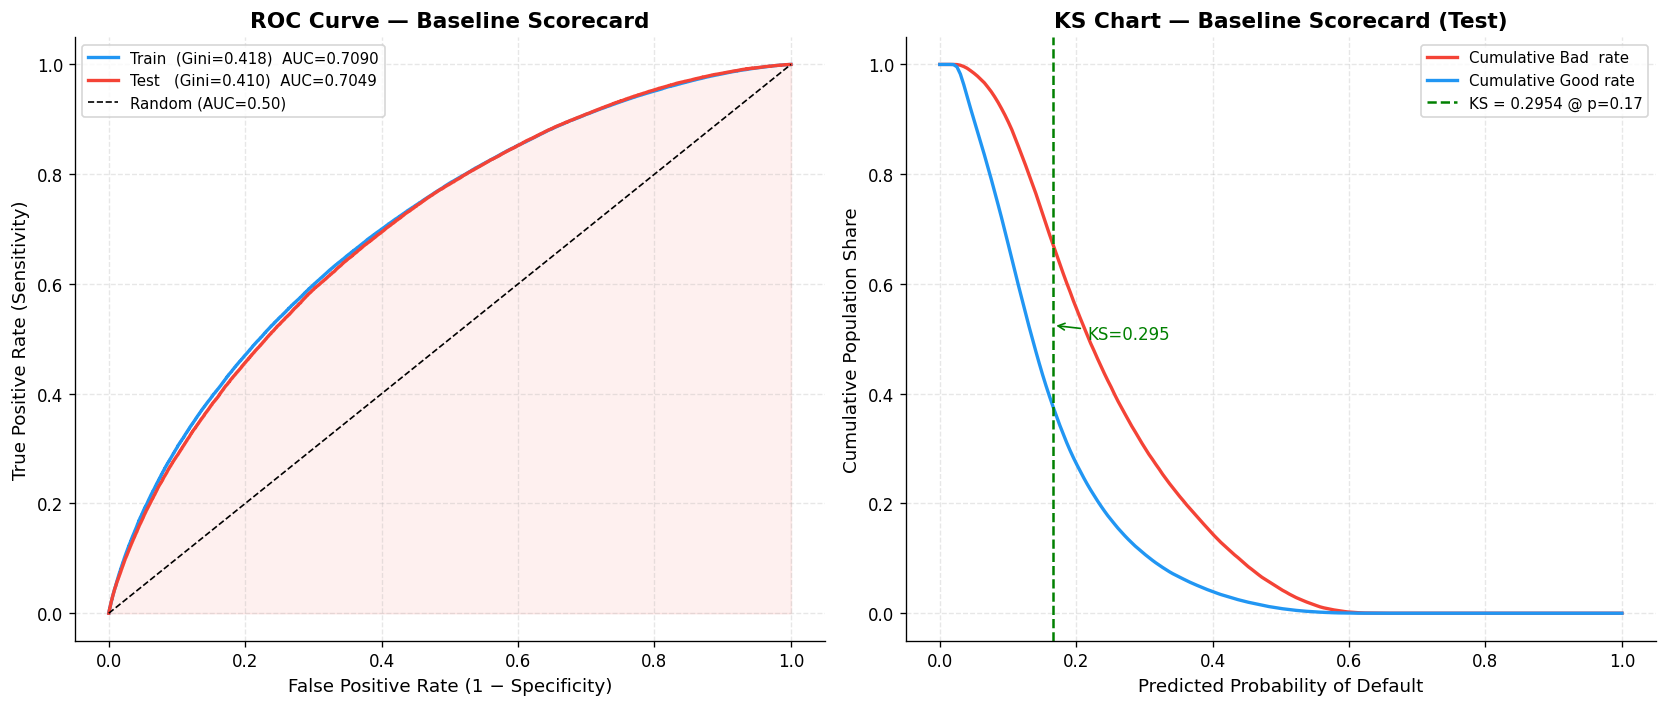

Saved: baseline_roc_ks.png


In [13]:
# Cell 13 — ROC Curve & KS Chart

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import roc_curve
import numpy as np

fig = plt.figure(figsize=(14, 6))
gs  = gridspec.GridSpec(1, 2, figure=fig)

# ── 1. ROC Curve ──────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])

for label, y_true, y_prob, color in [
    (f'Train  (Gini={train_gini:.3f})', y_train.values, train_proba, '#2196F3'),
    (f'Test   (Gini={test_gini:.3f})',  y_test.values,  test_proba,  '#F44336'),
]:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    ax1.plot(fpr, tpr, color=color, lw=2, label=f'{label}  AUC={auc:.4f}')

ax1.plot([0,1],[0,1],'k--', lw=1, label='Random (AUC=0.50)')
ax1.fill_between(*roc_curve(y_test.values, test_proba)[:2],
                 alpha=0.08, color='#F44336')
ax1.set_xlabel('False Positive Rate (1 − Specificity)', fontsize=11)
ax1.set_ylabel('True Positive Rate (Sensitivity)',       fontsize=11)
ax1.set_title('ROC Curve — Baseline Scorecard',          fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# ── 2. KS Chart ───────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])

# Use test set
thresholds  = np.linspace(0, 1, 200)
cum_good    = []
cum_bad     = []

y_t = y_test.values
p_t = test_proba

for thr in thresholds:
    above      = p_t >= thr
    cum_bad.append( y_t[above].sum()        / y_t.sum())
    cum_good.append((1 - y_t)[above].sum()  / (1 - y_t).sum())

cum_good = np.array(cum_good)
cum_bad  = np.array(cum_bad)
ks_vals  = np.abs(cum_bad - cum_good)
ks_idx   = np.argmax(ks_vals)
ks_thr   = thresholds[ks_idx]

ax2.plot(thresholds, cum_bad,  color='#F44336', lw=2, label='Cumulative Bad  rate')
ax2.plot(thresholds, cum_good, color='#2196F3', lw=2, label='Cumulative Good rate')
ax2.axvline(x=ks_thr, color='green', linestyle='--', lw=1.5,
            label=f'KS = {ks_vals[ks_idx]:.4f} @ p={ks_thr:.2f}')
ax2.annotate(f'KS={ks_vals[ks_idx]:.3f}',
             xy=(ks_thr, (cum_bad[ks_idx]+cum_good[ks_idx])/2),
             xytext=(ks_thr+0.05, 0.5), fontsize=10, color='green',
             arrowprops=dict(arrowstyle='->', color='green'))
ax2.set_xlabel('Predicted Probability of Default', fontsize=11)
ax2.set_ylabel('Cumulative Population Share',       fontsize=11)
ax2.set_title('KS Chart — Baseline Scorecard (Test)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('baseline_roc_ks.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: baseline_roc_ks.png")

### Scaling probabilities to a 300–850 score

Raw default probabilities aren't how credit decisions get communicated internally, so they're rescaled onto a FICO-style points scale using the standard PDO (points-to-double-odds) formula:

$$Score = Offset + Factor \times \ln(odds), \qquad Factor = \frac{PDO}{\ln 2}$$

anchored so a score of 600 corresponds to 50:1 good:bad odds, with 20 points doubling those odds. The score-band table is really a monotonicity check in disguise: bad rate should climb steadily as score falls, and confirming that here is what makes the 300–850 output trustworthy enough to hand to a business user.


Scaling parameters:
  PDO    : 20  (points to double odds)
  Anchor : 600 points @ 50:1 odds
  Factor : 28.8539
  Offset : 487.1229

Train score distribution:
  Min=467  Max=606  Mean=536  Std=24

Test score distribution:
  Min=465  Max=606  Mean=537  Std=24

Score Band Table — TRAIN
   band  Count   Bads  Bad_Rate  Pct_Volume
300-500  58745  26928     45.84         7.1
500-550 547345 111057     20.29        66.2
550-600 220403  14314      6.49        26.7
600-625    111      3      2.70         0.0

Score Band Table — TEST
   band  Count  Bads  Bad_Rate  Pct_Volume
300-500  20644 10753     52.09         7.0
500-550 189909 50121     26.39        64.8
550-600  82508  7367      8.93        28.2
600-625     34     1      2.94         0.0


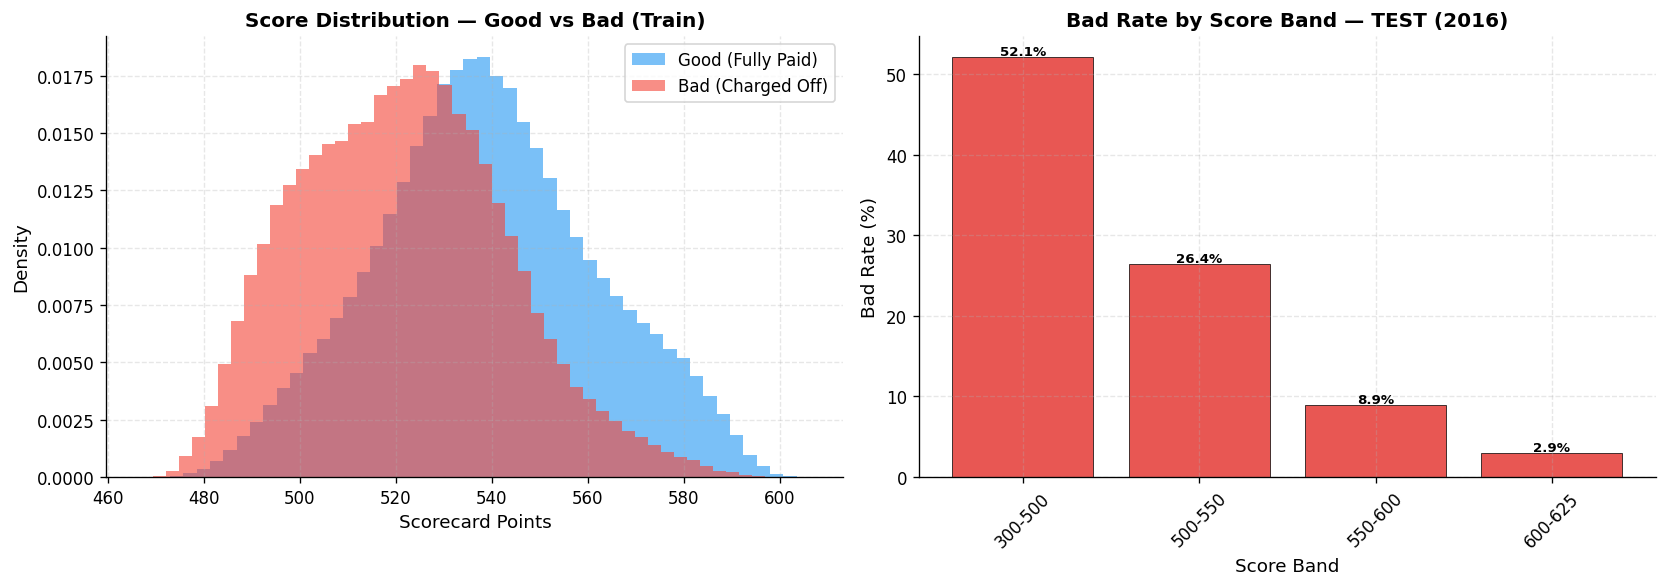


Saved: baseline_score_distribution.png

Phase 3 complete — Baseline scorecard built
   Test Gini : 0.4098  |  KS : 0.2957  |  AUC : 0.7049
   Score range : 300–850  |  PDO : 20  |  Anchor : 600 @ 50:1 odds


In [14]:
# Cell 14 — Scorecard Point Scaling (300–850)

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ── 1. Scaling constants (industry standard) ──────────────────────────────────
# Score = Offset + Factor × log(odds)
# Anchor: score=600 at odds=50:1 (good:bad), PDO=20 (points to double odds)

PDO    = 20
ODDS   = 50        # good:bad odds at anchor score
ANCHOR = 600       # anchor score

FACTOR = PDO / np.log(2)
OFFSET = ANCHOR - FACTOR * np.log(ODDS)

print(f"Scaling parameters:")
print(f"  PDO    : {PDO}  (points to double odds)")
print(f"  Anchor : {ANCHOR} points @ {ODDS}:1 odds")
print(f"  Factor : {FACTOR:.4f}")
print(f"  Offset : {OFFSET:.4f}")

# ── 2. Convert probabilities → log-odds → scores ──────────────────────────────
def prob_to_score(prob, factor=FACTOR, offset=OFFSET):
    prob   = np.clip(prob, 1e-7, 1 - 1e-7)
    odds   = (1 - prob) / prob          # good:bad odds
    logodds = np.log(odds)
    score  = offset + factor * logodds
    return np.clip(score, 300, 850)     # cap to FICO range

train_scores = prob_to_score(train_proba)
test_scores  = prob_to_score(test_proba)

print(f"\nTrain score distribution:")
print(f"  Min={train_scores.min():.0f}  Max={train_scores.max():.0f}"
      f"  Mean={train_scores.mean():.0f}  Std={train_scores.std():.0f}")
print(f"\nTest score distribution:")
print(f"  Min={test_scores.min():.0f}  Max={test_scores.max():.0f}"
      f"  Mean={test_scores.mean():.0f}  Std={test_scores.std():.0f}")

# ── 3. Score band analysis ────────────────────────────────────────────────────
def score_band_table(scores, y_true, label=''):
    bins   = [300, 500, 550, 600, 625, 650, 675, 700, 750, 850]
    labels = ['300-500','500-550','550-600','600-625',
              '625-650','650-675','675-700','700-750','750-850']
    bands  = pd.cut(scores, bins=bins, labels=labels, include_lowest=True)
    df_tmp = pd.DataFrame({'band': bands, 'bad': y_true})
    tbl    = (df_tmp.groupby('band', observed=True)['bad']
              .agg(Count='count', Bads='sum')
              .assign(Bad_Rate=lambda x: (x['Bads']/x['Count']*100).round(2))
              .reset_index())
    tbl['Pct_Volume'] = (tbl['Count'] / tbl['Count'].sum() * 100).round(1)
    print(f"\nScore Band Table — {label}")
    print(tbl.to_string(index=False))
    return tbl

train_band_tbl = score_band_table(train_scores, y_train.values, 'TRAIN')
test_band_tbl  = score_band_table(test_scores,  y_test.values,  'TEST')

# ── 4. Score distribution plot ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram — goods vs bads
ax = axes[0]
ax.hist(train_scores[y_train==0], bins=50, alpha=0.6,
        color='#2196F3', label='Good (Fully Paid)',  density=True)
ax.hist(train_scores[y_train==1], bins=50, alpha=0.6,
        color='#F44336', label='Bad (Charged Off)',  density=True)
ax.set_xlabel('Scorecard Points', fontsize=11)
ax.set_ylabel('Density',          fontsize=11)
ax.set_title('Score Distribution — Good vs Bad (Train)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Bad rate by score band (test)
ax2 = axes[1]
ax2.bar(test_band_tbl['band'].astype(str), test_band_tbl['Bad_Rate'],
        color='#E53935', alpha=0.85, edgecolor='black', linewidth=0.5)
ax2.set_xlabel('Score Band',       fontsize=11)
ax2.set_ylabel('Bad Rate (%)',     fontsize=11)
ax2.set_title('Bad Rate by Score Band — TEST (2016)', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)
for i, row in test_band_tbl.iterrows():
    ax2.text(i, row['Bad_Rate']+0.3, f"{row['Bad_Rate']:.1f}%",
             ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('baseline_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: baseline_score_distribution.png")
print(f"\nPhase 3 complete — Baseline scorecard built")
print(f"   Test Gini : 0.4098  |  KS : 0.2957  |  AUC : 0.7049")
print(f"   Score range : 300–850  |  PDO : 20  |  Anchor : 600 @ 50:1 odds")



### Persisting baseline artifacts

The trained model, WoE tables, selected feature list, and baseline metrics are serialised with `joblib` so that reject inference, the dashboard, and the Streamlit app can all load them directly instead of retraining from scratch.


In [15]:
import os, joblib

os.makedirs('saved_objects', exist_ok=True)
df_model.to_csv('saved_objects/df_model.csv', index=False)
df_woe.to_csv('saved_objects/df_woe.csv', index=False)
joblib.dump(lr_model, 'saved_objects/lr_model.pkl')
joblib.dump(woe_tables, 'saved_objects/woe_tables.pkl')
joblib.dump(SELECTED_FEATURES, 'saved_objects/selected_features.pkl')
joblib.dump(metrics, 'saved_objects/baseline_metrics.pkl')

print("Baseline artifacts saved to saved_objects/")

Baseline artifacts saved to saved_objects/


## Phase 4 — Reject Inference

The baseline model above was trained only on applicants LendingClub already chose to fund — which means it inherited LendingClub's own underwriting bias and has never seen the population it would actually need to evaluate in production: the applicants who got rejected. Reject inference is the set of techniques that try to correct for this. Three are implemented here, starting with the most direct.


### Method 1 — Augmentation
 The baseline model scores every rejected applicant; those predicted probabilities become soft labels (rounded to 0/1 for compatibility with plain `LogisticRegression`), sampled 1:1 against the accepted training set so the reject population doesn't overwhelm the real signal, and the model is retrained on the combined set. Only 3 of the 10 selected features actually exist in the rejected-loan file (it has 9 raw columns against 151 for accepted loans), so this is inherently a limited correction rather than a full fix — worth knowing going in, since it caps how much uplift any of the three methods can realistically deliver.

In [16]:
# ============================================================
# CELL 15 — Reject Inference: Method 1 — Augmentation
# Idea: score all rejected applicants using baseline model,
# assign soft probability labels, combine with accepted loans,
# retrain. Corrects sample selection bias.
# ============================================================

print("Step 1/4 — Aligning rejected data...")

# Rejected dataset has 9 columns — map to our feature names
rej_clean = rej.copy()
rej_clean.columns = rej_clean.columns.str.strip()

# Rename to match accepted feature names
rej_clean = rej_clean.rename(columns={
    'Amount Requested'   : 'loan_amnt',
    'Debt-To-Income Ratio': 'dti',
    'Employment Length'  : 'emp_length',
    'State'              : 'addr_state',
    'Risk_Score'         : 'fico_avg',
})

# Clean dti — has % sign in rejected data
rej_clean['dti'] = (rej_clean['dti']
                    .astype(str)
                    .str.replace('%','', regex=False)
                    .str.strip())
rej_clean['dti'] = pd.to_numeric(rej_clean['dti'], errors='coerce')
rej_clean['dti'] = rej_clean['dti'].fillna(rej_clean['dti'].median())

# emp_length → numeric
rej_clean['emp_length_num'] = rej_clean['emp_length'].map(
    {'< 1 year':0,'1 year':1,'2 years':2,'3 years':3,
     '4 years':4,'5 years':5,'6 years':6,'7 years':7,
     '8 years':8,'9 years':9,'10+ years':10}
).fillna(-1)

# state risk tier
high_risk = ['MS','NE','AR','AL','OK','LA','NV','IN',
             'TN','MO','GA','KY','OH','MI','TX']
low_risk  = ['NH','OR','VT','ME','DC','IA','ND','SD',
             'WI','MN','CO','WA','MA','CT','NJ']
rej_clean['state_risk_tier'] = rej_clean['addr_state'].map(
    lambda s: 'high_risk' if str(s) in high_risk
              else 'low_risk' if str(s) in low_risk
              else 'medium_risk')

# loan_amnt — cap same bounds as accepted
rej_clean['loan_amnt'] = pd.to_numeric(
    rej_clean['loan_amnt'], errors='coerce')
rej_clean['loan_amnt'] = rej_clean['loan_amnt'].clip(1500, 35000)

# fico_avg — cap same bounds
rej_clean['fico_avg'] = pd.to_numeric(
    rej_clean['fico_avg'], errors='coerce')

print(f"   rej_clean shape: {rej_clean.shape}")
print(f"   Columns available: {list(rej_clean.columns)}")

# ── Which SELECTED_FEATURES exist in rejected data? ──────────
print("\nStep 2/4 — Feature availability check...")
available   = []
unavailable = []
for f in SELECTED_FEATURES:
    if f in rej_clean.columns:
        available.append(f)
    else:
        unavailable.append(f)

print(f"   Available in rejected data : {available}")
print(f"   NOT available              : {unavailable}")
print(f"   Coverage: {len(available)}/{len(SELECTED_FEATURES)} features")
print("Step 3/4 — WoE transform rejected data + impute missing...")

# Apply WoE to available features, impute missing with 0.0
# WoE of 0.0 = log(1) = neutral — no good/bad signal
# This is conservative and standard practice

rej_woe = pd.DataFrame(index=rej_clean.index)

for feat in SELECTED_FEATURES:
    cat_flag = feat in CAT_FEATURES or feat == 'miss_emp_length'
    if feat in rej_clean.columns:
        # Apply WoE transformation
        wt = woe_tables[feat]
        if cat_flag:
            woe_map = dict(zip(wt['bin'].astype(str), wt['woe']))
            rej_woe[feat] = rej_clean[feat].astype(str).map(woe_map).fillna(0.0)
        else:
            edges = [-np.inf]
            if hasattr(wt['bin'].iloc[0], 'right'):
                for interval in wt['bin']:
                    edges.append(interval.right)
            edges[-1] = np.inf
            edges[0]  = -np.inf
            edges = sorted(set(edges))
            vals    = pd.to_numeric(rej_clean[feat], errors='coerce').fillna(0)
            bin_idx = np.digitize(vals.values, edges[1:], right=True)
            bin_idx = np.clip(bin_idx, 0, len(wt)-1)
            rej_woe[feat] = wt['woe'].values[bin_idx]
    else:
        # Impute with 0.0 — neutral WoE
        rej_woe[feat] = 0.0

print(f"   rej_woe shape : {rej_woe.shape}")
print(f"   Nulls         : {rej_woe.isnull().sum().sum()}")

# ── Score all rejected applicants ────────────────────────────
rej_prob = lr_model.predict_proba(rej_woe)[:, 1]
print(f"\n   Rejected applicants — predicted P(default):")
print(f"   Mean  : {rej_prob.mean():.4f}")
print(f"   Median: {np.median(rej_prob):.4f}")
print(f"   Min   : {rej_prob.min():.4f}")
print(f"   Max   : {rej_prob.max():.4f}")

# ── Assign soft labels ────────────────────────────────────────
# Soft label = predicted probability itself (not hard 0/1)
# This preserves uncertainty — we don't force a binary decision
# on applicants we've never observed
rej_woe['soft_label'] = rej_prob

print("\nStep 4/4 — Augmentation: combine + retrain...")

# Sample rejects — use same size as training set to avoid
# overwhelming the accepted signal (1:1 ratio)
n_sample = len(X_train)
rej_sample = rej_woe.sample(n=n_sample, random_state=42)

# Build augmented training set
X_aug = pd.concat([
    X_train,
    rej_sample[SELECTED_FEATURES]
], ignore_index=True)

# Hard labels for accepted + soft labels for rejects
# For soft labels we round to nearest 0/1 for sklearn
# (true soft-label LR requires custom implementation)
y_aug_accepted = y_train.values
y_aug_rejected = (rej_sample['soft_label'].values > 0.5).astype(int)
y_aug = np.concatenate([y_aug_accepted, y_aug_rejected])

print(f"   Augmented train size : {len(X_aug):,}")
print(f"   Accepted portion     : {len(X_train):,}")
print(f"   Rejected portion     : {len(rej_sample):,}")
print(f"   Augmented bad rate   : {y_aug.mean():.4f}")

# ── 1. Retrain the model ────────────────────
lr_aug = LogisticRegression(max_iter=1000, random_state=42)
lr_aug.fit(X_aug, y_aug)

# ── 2. Evaluate on SAME test set as baseline ──────────────────────────────────
y_aug_prob = lr_aug.predict_proba(X_test)[:, 1]
auc_aug  = roc_auc_score(y_test, y_aug_prob)
gini_aug = 2 * auc_aug - 1

# ── 3. Calculate KS Statistic ─────────────────────────────────────────────────
import scipy.stats as stats
ks_aug   = stats.ks_2samp(
    y_aug_prob[y_test.values==0],
    y_aug_prob[y_test.values==1]).statistic

# ── 4. Map baseline variables to match Cell 12 names ──────────────────────────
auc  = test_auc
gini = test_gini
ks   = test_ks

print(f"\n{'='*50}")
print(f"  METHOD 1 — AUGMENTATION RESULTS")
print(f"{'='*50}")
print(f"  {'Metric':<10} {'Baseline':>12} {'Augmented':>12} {'Delta':>10}")
print(f"  {'-'*46}")
print(f"  {'AUC':<10} {auc:>12.4f} {auc_aug:>12.4f} "
      f"{auc_aug-auc:>+10.4f}")
print(f"  {'Gini':<10} {gini:>12.4f} {gini_aug:>12.4f} "
      f"{gini_aug-gini:>+10.4f}")
print(f"  {'KS':<10} {ks:>12.4f} {ks_aug:>12.4f} "
      f"{ks_aug-ks:>+10.4f}")

# Save for comparison
import joblib
joblib.dump(lr_aug, 'saved_objects/lr_aug.pkl')
joblib.dump({'auc':auc_aug,'gini':gini_aug,'ks':ks_aug},
            'saved_objects/metrics_aug.pkl')
print(f"\nMethod 1 complete. lr_aug saved.")



Step 1/4 — Aligning rejected data...
   rej_clean shape: (27648741, 11)
   Columns available: ['loan_amnt', 'Application Date', 'Loan Title', 'fico_avg', 'dti', 'Zip Code', 'addr_state', 'emp_length', 'Policy Code', 'emp_length_num', 'state_risk_tier']

Step 2/4 — Feature availability check...
   Available in rejected data : ['fico_avg', 'dti', 'loan_amnt']
   NOT available              : ['int_rate', 'term', 'verification_status', 'home_ownership', 'installment', 'annual_inc', 'revol_util']
   Coverage: 3/10 features
Step 3/4 — WoE transform rejected data + impute missing...
   rej_woe shape : (27648741, 10)
   Nulls         : 0

   Rejected applicants — predicted P(default):
   Mean  : 0.2165
   Median: 0.2108
   Min   : 0.0930
   Max   : 0.2828

Step 4/4 — Augmentation: combine + retrain...
   Augmented train size : 1,653,208
   Accepted portion     : 826,604
   Rejected portion     : 826,604
   Augmented bad rate   : 0.0921

  METHOD 1 — AUGMENTATION RESULTS
  Metric         Baseli

### Method 2 — Fuzzy Parcelling

Rather than forcing each reject to a hard 0 or 1, every sampled reject (200K, for tractability) contributes two weighted training rows: one labelled good with weight $1-\hat p$, one labelled bad with weight $\hat p$, where $\hat p$ is the baseline model's predicted default probability. Fitting with `sample_weight` lets both rows contribute proportionally to how confident the original prediction actually was — a more honest treatment of genuine uncertainty than Method 1's rounded soft labels.


In [17]:
# ============================================================
# CELL 16 — Reject Inference: Method 2 — Fuzzy Parcelling
# Idea: bin rejects by predicted P(default), assign weighted
# good/bad labels within each bin proportional to the bin's
# average probability. More principled than hard 0/1 labels.
# ============================================================

print("Step 1/3 — Fuzzy parcelling of rejected applicants...")

# Use scores already computed in Cell 15
rej_woe['pred_prob'] = rej_prob

# Bin rejects into 10 parcels by predicted probability
rej_woe['parcel'] = pd.qcut(
    rej_woe['pred_prob'], q=10, labels=False, duplicates='drop')

parcel_stats = (rej_woe.groupby('parcel')['pred_prob']
                .agg(['count','mean','min','max'])
                .reset_index())
parcel_stats.columns = ['parcel','count','avg_prob','min_prob','max_prob']

print(f"\n  {'Parcel':<8} {'Count':>12} {'Avg P(def)':>12} "
      f"{'Min':>8} {'Max':>8}")
print(f"  {'-'*52}")
for _, row in parcel_stats.iterrows():
    print(f"  {int(row['parcel']):<8} {int(row['count']):>12,} "
          f"{row['avg_prob']:>12.4f} {row['min_prob']:>8.4f} "
          f"{row['max_prob']:>8.4f}")

print("\nStep 2/3 — Assign weighted labels + build training set...")

# For each reject, assign:
# P(bad)  = predicted probability (fuzzy bad weight)
# P(good) = 1 - predicted probability (fuzzy good weight)
# Each reject contributes TWO weighted rows — one good, one bad
# This preserves the uncertainty rather than forcing a hard label

# Sample rejects for computational efficiency
n_sample  = min(200000, len(rej_woe))
rej_fuzzy = rej_woe.sample(n=n_sample, random_state=42).copy()

# Good copies — weight = 1 - pred_prob, label = 0
rej_good          = rej_fuzzy[SELECTED_FEATURES].copy()
rej_good['label'] = 0
rej_good['weight']= 1 - rej_fuzzy['pred_prob'].values

# Bad copies — weight = pred_prob, label = 1
rej_bad           = rej_fuzzy[SELECTED_FEATURES].copy()
rej_bad['label']  = 1
rej_bad['weight'] = rej_fuzzy['pred_prob'].values

# Combine rejects (good + bad copies) with accepted training
X_fuzzy = pd.concat([
    X_train,
    rej_good[SELECTED_FEATURES],
    rej_bad[SELECTED_FEATURES]
], ignore_index=True)

y_fuzzy = np.concatenate([
    y_train.values,
    rej_good['label'].values,
    rej_bad['label'].values
])

w_fuzzy = np.concatenate([
    np.ones(len(y_train)),        # accepted: full weight = 1
    rej_good['weight'].values,    # rejected good copies
    rej_bad['weight'].values      # rejected bad copies
])

print(f"   Total training rows  : {len(X_fuzzy):,}")
print(f"   Accepted             : {len(X_train):,}")
print(f"   Rejected (2x copies) : {len(rej_good)*2:,}")
print(f"   Weighted bad rate    : {np.average(y_fuzzy, weights=w_fuzzy):.4f}")

print("\nStep 3/3 — Retrain with sample weights...")
lr_fuzzy = LogisticRegression(max_iter=1000, random_state=42)
lr_fuzzy.fit(X_fuzzy, y_fuzzy, sample_weight=w_fuzzy)

# Evaluate on same test set
y_fuzzy_prob = lr_fuzzy.predict_proba(X_test)[:, 1]
auc_fuzzy  = roc_auc_score(y_test, y_fuzzy_prob)
gini_fuzzy = 2 * auc_fuzzy - 1
ks_fuzzy   = stats.ks_2samp(
    y_fuzzy_prob[y_test.values==0],
    y_fuzzy_prob[y_test.values==1]).statistic

print(f"\n{'='*55}")
print(f"  METHOD 2 — FUZZY PARCELLING RESULTS")
print(f"{'='*55}")
print(f"  {'Metric':<10} {'Baseline':>10} {'Augment':>10} "
      f"{'Fuzzy':>10} {'Delta':>10}")
print(f"  {'-'*50}")
print(f"  {'AUC':<10} {auc:>10.4f} {auc_aug:>10.4f} "
      f"{auc_fuzzy:>10.4f} {auc_fuzzy-auc:>+10.4f}")
print(f"  {'Gini':<10} {gini:>10.4f} {gini_aug:>10.4f} "
      f"{gini_fuzzy:>10.4f} {gini_fuzzy-gini:>+10.4f}")
print(f"  {'KS':<10} {ks:>10.4f} {ks_aug:>10.4f} "
      f"{ks_fuzzy:>10.4f} {ks_fuzzy-ks:>+10.4f}")

joblib.dump(lr_fuzzy, 'saved_objects/lr_fuzzy.pkl')
joblib.dump({'auc':auc_fuzzy,'gini':gini_fuzzy,'ks':ks_fuzzy},
            'saved_objects/metrics_fuzzy.pkl')
print(f"\nMethod 2 complete. lr_fuzzy saved.")

Step 1/3 — Fuzzy parcelling of rejected applicants...

  Parcel          Count   Avg P(def)      Min      Max
  ----------------------------------------------------
  0           4,106,960       0.1620   0.0930   0.1693
  1           2,135,110       0.1735   0.1693   0.1753
  2           2,251,519       0.1813   0.1754   0.1848
  3           3,017,028       0.1897   0.1849   0.1947
  4           2,658,143       0.2038   0.1947   0.2108
  5           2,518,441       0.2205   0.2108   0.2290
  6           4,856,399       0.2490   0.2290   0.2573
  7             935,588       0.2594   0.2577   0.2609
  8           2,946,347       0.2704   0.2625   0.2775
  9           2,223,206       0.2807   0.2780   0.2828

Step 2/3 — Assign weighted labels + build training set...
   Total training rows  : 1,226,604
   Accepted             : 826,604
   Rejected (2x copies) : 400,000
   Weighted bad rate    : 0.1905

Step 3/3 — Retrain with sample weights...

  METHOD 2 — FUZZY PARCELLING RESULTS
  Metri

### Method 3 — Self-learning

The most conservative of the three: only rejects the model is genuinely confident about get labelled at all. Because the rejected population's scores are compressed into a narrow band rather than spanning the fixed 0.30/0.70 split used conventionally, the thresholds here are set adaptively from the reject pool's own 30th/70th percentiles. Over five iterations, confidently-labelled rejects are added to the training set, the model is retrained, and the thresholds are refreshed from the newly retrained model before the next round — a standard semi-supervised self-training loop. The comparison table at the end brings baseline and all three reject inference methods together on the same test set for the first time.


In [18]:
# ============================================================
# CELL 17 — Reject Inference: Method 3 — Self Learning
# Idea: only label rejects where the model is highly confident
# (P > 0.70 = likely bad, P < 0.30 = likely good).
# Iterate 5 times, each time adding confident rejects.
# More conservative — avoids polluting training with
# uncertain labels.
# ============================================================

print("Self Learning — 5 iterations")
print(f"Confidence thresholds: P < 0.30 = Good, P > 0.70 = Bad")
print(f"(Note: given compressed score range 0.09-0.28,")
print(f" we will adaptively use percentile thresholds)\n")

# ── Adaptive thresholds based on actual score distribution ───
p30 = np.percentile(rej_prob, 30)   # bottom 30% → label Good
p70 = np.percentile(rej_prob, 70)   # top 70% → label Bad
print(f"Adaptive thresholds (percentile-based):")
print(f"  P(default) < {p30:.4f} → label Good (0)")
print(f"  P(default) > {p70:.4f} → label Bad  (1)")

# ── Sample rejects for efficiency ────────────────────────────
rej_pool = rej_woe[SELECTED_FEATURES + ['pred_prob']].sample(
    n=min(500000, len(rej_woe)), random_state=42).copy()

# Tracking across iterations
iteration_metrics = []
current_model     = lr_model   # start from baseline
X_iter            = X_train.copy()
y_iter            = y_train.copy()

for iteration in range(1, 6):

    # Score reject pool with current model
    iter_probs = current_model.predict_proba(
        rej_pool[SELECTED_FEATURES])[:, 1]

    # Label high-confidence rejects only
    good_mask = iter_probs < p30
    bad_mask  = iter_probs > p70

    rej_good_idx = rej_pool[good_mask].index
    rej_bad_idx  = rej_pool[bad_mask].index

    n_good_added = good_mask.sum()
    n_bad_added  = bad_mask.sum()
    n_uncertain  = (~good_mask & ~bad_mask).sum()

    # Add labelled rejects to training data
    X_new_good = rej_pool.loc[rej_good_idx, SELECTED_FEATURES]
    X_new_bad  = rej_pool.loc[rej_bad_idx,  SELECTED_FEATURES]
    y_new_good = np.zeros(n_good_added, dtype=int)
    y_new_bad  = np.ones(n_bad_added,  dtype=int)

    X_iter_new = pd.concat(
        [X_iter, X_new_good, X_new_bad], ignore_index=True)
    y_iter_new = np.concatenate(
        [y_iter.values, y_new_good, y_new_bad])

    # Retrain
    iter_model = LogisticRegression(max_iter=1000, random_state=42)
    iter_model.fit(X_iter_new, y_iter_new)

    # Evaluate
    y_iter_prob = iter_model.predict_proba(X_test)[:, 1]
    auc_i  = roc_auc_score(y_test, y_iter_prob)
    gini_i = 2 * auc_i - 1
    ks_i   = stats.ks_2samp(
        y_iter_prob[y_test.values==0],
        y_iter_prob[y_test.values==1]).statistic

    iteration_metrics.append({
        'iteration'   : iteration,
        'n_good_added': n_good_added,
        'n_bad_added' : n_bad_added,
        'n_uncertain' : n_uncertain,
        'train_size'  : len(X_iter_new),
        'auc'         : auc_i,
        'gini'        : gini_i,
        'ks'          : ks_i
    })

    print(f"Iter {iteration}: "
          f"Good+={n_good_added:>7,} Bad+={n_bad_added:>7,} "
          f"Uncertain={n_uncertain:>7,} | "
          f"AUC={auc_i:.4f} Gini={gini_i:.4f} KS={ks_i:.4f}")

    # Update for next iteration
    current_model = iter_model
    X_iter        = X_iter_new
    y_iter        = pd.Series(y_iter_new)

    # Update thresholds based on new model
    iter_all_probs = current_model.predict_proba(
        rej_pool[SELECTED_FEATURES])[:, 1]
    p30 = np.percentile(iter_all_probs, 30)
    p70 = np.percentile(iter_all_probs, 70)

# ── Final self-learning model = last iteration ────────────────
lr_self   = current_model
auc_self  = iteration_metrics[-1]['auc']
gini_self = iteration_metrics[-1]['gini']
ks_self   = iteration_metrics[-1]['ks']

# ── Full comparison table ─────────────────────────────────────
print(f"\n{'='*62}")
print(f"  PHASE 4 COMPLETE — ALL METHODS COMPARED")
print(f"{'='*62}")
print(f"  {'Method':<22} {'AUC':>8} {'Gini':>8} {'KS':>8} {'vs Baseline'}")
print(f"  {'-'*58}")
methods = [
    ('Baseline (accepted)',  auc,       gini,       ks),
    ('Method 1: Augment',   auc_aug,   gini_aug,   ks_aug),
    ('Method 2: Fuzzy',     auc_fuzzy, gini_fuzzy, ks_fuzzy),
    ('Method 3: Self-Learn',auc_self,  gini_self,  ks_self),
]
for name, a, g, k in methods:
    delta = f"{a-auc:+.4f}" if name != 'Baseline (accepted)' else '—'
    print(f"  {name:<22} {a:>8.4f} {g:>8.4f} {k:>8.4f} {delta:>12}")

# Save
lr_self_final = current_model
joblib.dump(lr_self_final, 'saved_objects/lr_self.pkl')
joblib.dump({'auc':auc_self,'gini':gini_self,'ks':ks_self},
            'saved_objects/metrics_self.pkl')

print(f"\nPhase 4 complete. All 3 methods done.")
print(f"   Best model by AUC: ", end="")
best = max(methods, key=lambda x: x[1])
print(f"{best[0]} — AUC {best[1]:.4f}")

Self Learning — 5 iterations
Confidence thresholds: P < 0.30 = Good, P > 0.70 = Bad
(Note: given compressed score range 0.09-0.28,
 we will adaptively use percentile thresholds)

Adaptive thresholds (percentile-based):
  P(default) < 0.1848 → label Good (0)
  P(default) > 0.2573 → label Bad  (1)
Iter 1: Good+=148,026 Bad+=110,452 Uncertain=241,522 | AUC=0.6640 Gini=0.3281 KS=0.2334
Iter 2: Good+=148,725 Bad+=140,483 Uncertain=210,792 | AUC=0.6505 Gini=0.3009 KS=0.2150
Iter 3: Good+=149,425 Bad+=146,393 Uncertain=204,182 | AUC=0.6444 Gini=0.2888 KS=0.2064
Iter 4: Good+=149,736 Bad+=148,820 Uncertain=201,444 | AUC=0.6407 Gini=0.2814 KS=0.2013
Iter 5: Good+=149,761 Bad+=148,942 Uncertain=201,297 | AUC=0.6382 Gini=0.2765 KS=0.1977

  PHASE 4 COMPLETE — ALL METHODS COMPARED
  Method                      AUC     Gini       KS vs Baseline
  ----------------------------------------------------------
  Baseline (accepted)      0.7049   0.4098   0.2957            —
  Method 1: Augment        0.6

## Phase 5 — Model Comparison & Population Stability

All four models — baseline plus the three reject inference variants — are reloaded and scored on the identical 2016 test set, which is what makes the comparison fair: any difference in AUC, Gini, or KS here reflects the reject inference method itself, not a different evaluation population.


  PHASE 5 — MODEL COMPARISON TABLE
  Evaluation on held-out test set (2016 vintage)
  Model                             AUC     Gini       KS
  --------------------------------------------------------
  Baseline (Accepted Only)       0.7049   0.4098   0.2957
  Method 1: Augmentation         0.6748   0.3497   0.2537
  Method 2: Fuzzy Parcelling     0.7049   0.4098   0.2958 ← best
  Method 3: Self Learning        0.6382   0.2765   0.1977


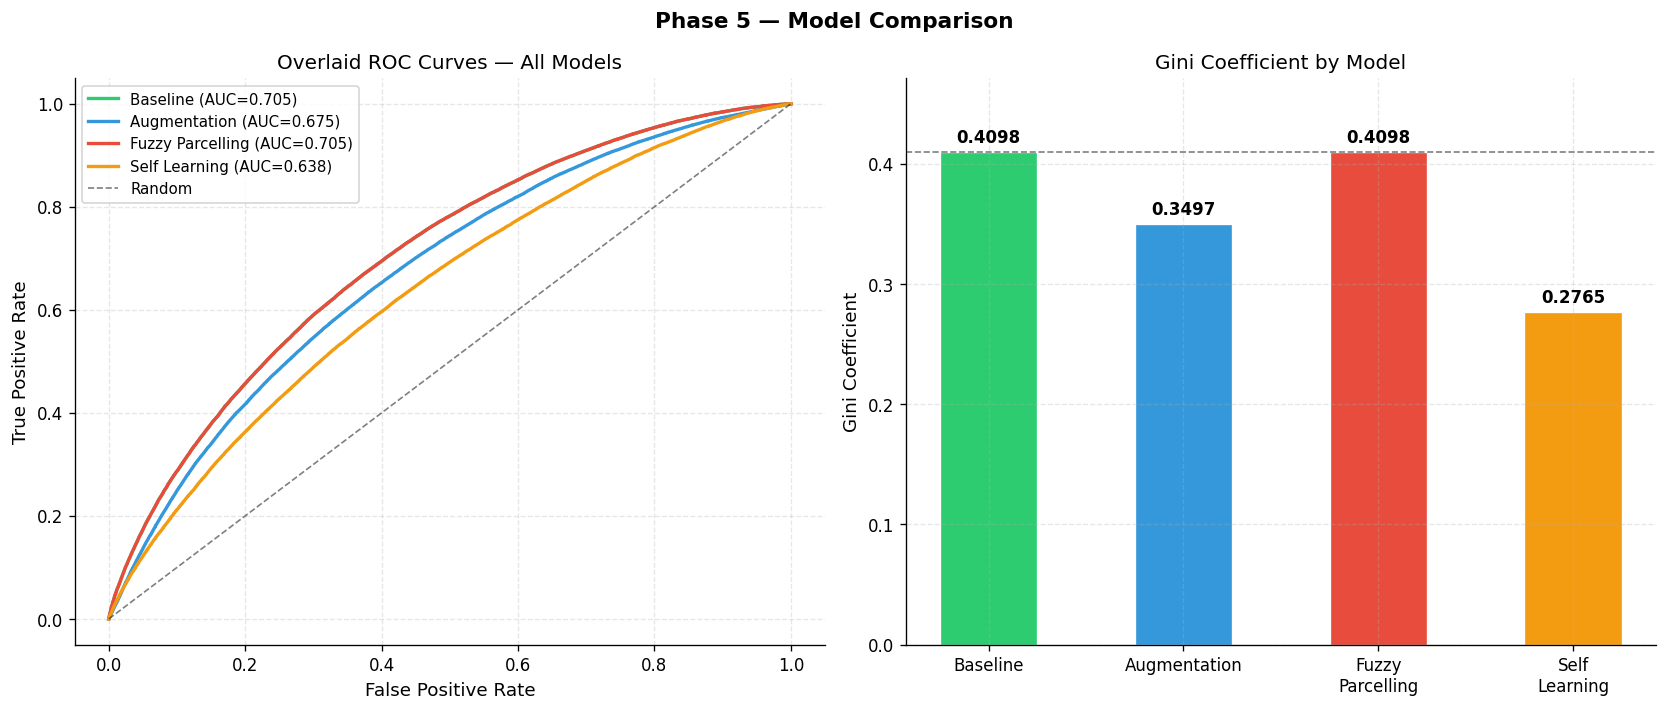


Plot saved:  model_comparison.png


In [19]:
# ============================================================
# CELL 18 — Model comparison: all 4 models
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import roc_curve
import numpy as np
import joblib
from scipy import stats

# ── Reload all models if needed ──────────────────────────────
lr_aug   = joblib.load('saved_objects/lr_aug.pkl')
lr_fuzzy = joblib.load('saved_objects/lr_fuzzy.pkl')
lr_self  = joblib.load('saved_objects/lr_self.pkl')

# ── Generate predictions from all models ─────────────────────
prob_baseline = lr_model.predict_proba(X_test)[:, 1]
prob_aug      = lr_aug.predict_proba(X_test)[:, 1]
prob_fuzzy    = lr_fuzzy.predict_proba(X_test)[:, 1]
prob_self     = lr_self.predict_proba(X_test)[:, 1]

# ── Helper: compute all metrics ──────────────────────────────
def get_metrics(y_true, y_prob, name):
    from sklearn.metrics import roc_auc_score
    auc  = roc_auc_score(y_true, y_prob)
    gini = 2 * auc - 1
    ks   = stats.ks_2samp(
        y_prob[y_true.values==0],
        y_prob[y_true.values==1]).statistic
    return {'model': name, 'auc': auc, 'gini': gini, 'ks': ks}

results = [
    get_metrics(y_test, prob_baseline, 'Baseline (Accepted Only)'),
    get_metrics(y_test, prob_aug,      'Method 1: Augmentation'),
    get_metrics(y_test, prob_fuzzy,    'Method 2: Fuzzy Parcelling'),
    get_metrics(y_test, prob_self,     'Method 3: Self Learning'),
]

import pandas as pd
results_df = pd.DataFrame(results)

print("=" * 62)
print("  PHASE 5 — MODEL COMPARISON TABLE")
print("  Evaluation on held-out test set (2016 vintage)")
print("=" * 62)
print(f"  {'Model':<28} {'AUC':>8} {'Gini':>8} {'KS':>8}")
print(f"  {'-'*56}")
for _, row in results_df.iterrows():
    marker = ' ← best' if row['auc'] == results_df['auc'].max() else ''
    print(f"  {row['model']:<28} {row['auc']:>8.4f} "
          f"{row['gini']:>8.4f} {row['ks']:>8.4f}{marker}")

# ── Overlaid ROC curves ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Phase 5 — Model Comparison', fontsize=13, fontweight='bold')

colors  = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
models  = [
    ('Baseline', prob_baseline),
    ('Augmentation', prob_aug),
    ('Fuzzy Parcelling', prob_fuzzy),
    ('Self Learning', prob_self),
]

ax1 = axes[0]
for (name, prob), color in zip(models, colors):
    from sklearn.metrics import roc_auc_score
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val     = roc_auc_score(y_test, prob)
    ax1.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{name} (AUC={auc_val:.3f})')

ax1.plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.5, label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Overlaid ROC Curves — All Models')
ax1.legend(fontsize=9)

# ── Gini bar chart ────────────────────────────────────────────
ax2 = axes[1]
gini_vals  = results_df['gini'].values
model_names = ['Baseline', 'Augmentation', 'Fuzzy\nParcelling', 'Self\nLearning']
bars = ax2.bar(model_names, gini_vals, color=colors,
               edgecolor='white', linewidth=0.8, width=0.5)

for bar, val in zip(bars, gini_vals):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', va='bottom',
             fontsize=10, fontweight='bold')

ax2.set_ylabel('Gini Coefficient')
ax2.set_title('Gini Coefficient by Model')
ax2.set_ylim(0, max(gini_vals) * 1.15)
ax2.axhline(gini_vals[0], color='black', linestyle='--',
            linewidth=1, alpha=0.5, label='Baseline')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("\nPlot saved:  model_comparison.png")

### Population Stability Index (PSI)

PSI answers a different question than AUC or KS: not "does the model still rank risk correctly," but "has the population being scored drifted from the population the model was built on." It's computed by comparing the model's score distribution on train (2007–2015) against test (2016) across ten percentile-based bins:

$$PSI = \sum \left(Actual\% - Expected\%\right) \times \ln\left(\frac{Actual\%}{Expected\%}\right)$$

with the conventional bands applied: under 0.10 is stable, 0.10–0.25 warrants monitoring, and above 0.25 signals the model needs rebuilding. This is the metric a bank actually watches post-deployment, since AUC against ground truth isn't available in real time on a live population — you don't know who defaults until later.


  PSI — POPULATION STABILITY INDEX
  Training (2007-2015) vs Test (2016)
  Model                             PSI  Status
  -------------------------------------------------------
  Baseline (Accepted Only)       0.0038  Stable ✅
  Method 1: Augmentation         0.0234  Stable ✅
  Method 2: Fuzzy Parcelling     0.0038  Stable ✅
  Method 3: Self Learning        0.0141  Stable ✅

  BASELINE PSI — bin-level breakdown
    Bin    Expected%      Actual%  PSI contrib
  --------------------------------------------
      1      0.1000       0.1029     0.000081
      2      0.1000       0.1052     0.000267
      3      0.1000       0.1109     0.001121
      4      0.1000       0.1071     0.000489
      5      0.1000       0.1021     0.000044
      6      0.1000       0.0963     0.000137
      7      0.1000       0.0919     0.000683
      8      0.1000       0.0944     0.000318
      9      0.1000       0.0930     0.000507
     10      0.1000       0.0961     0.000153


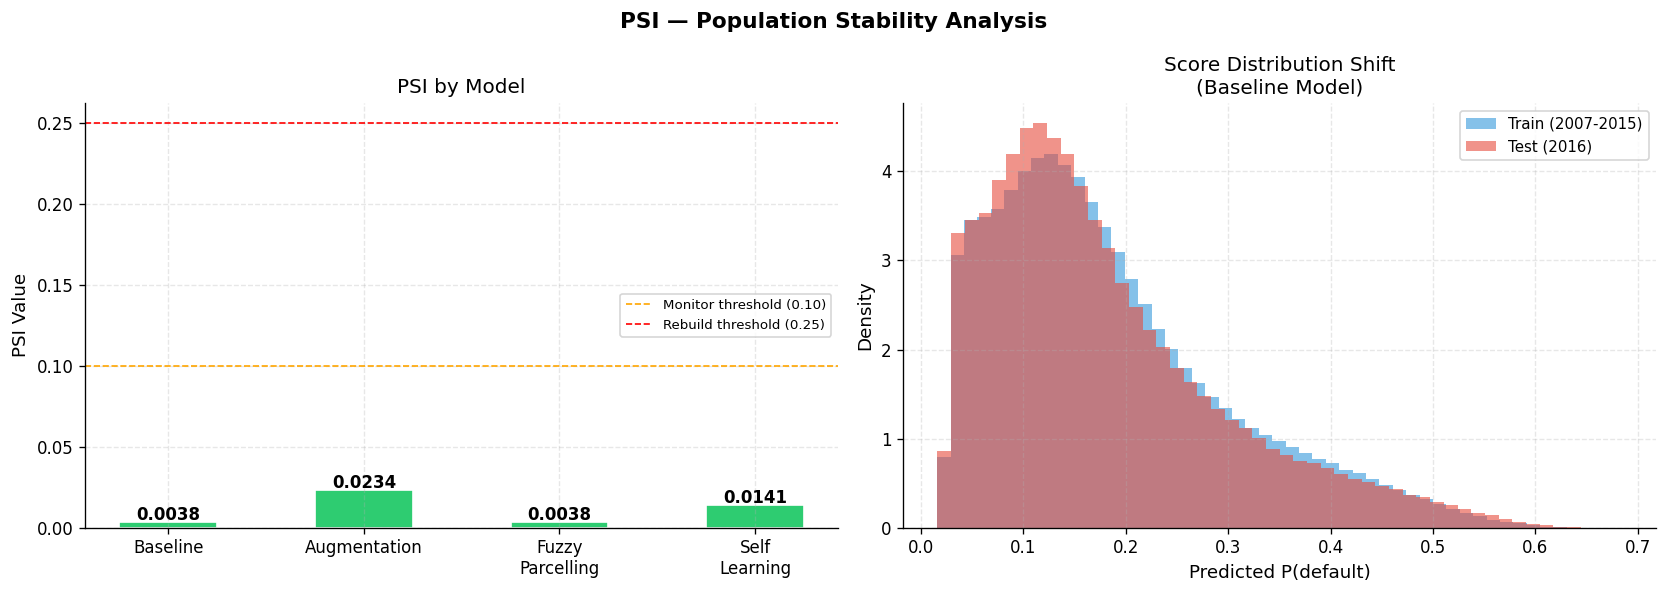


PSI complete.
Saved iv_display.pkl and psi_display.pkl for the Streamlit app.


In [20]:
# ============================================================
# CELL 19 — Population Stability Index (PSI)
# PSI measures whether the scoring population has shifted
# between training (2007-2015) and test (2016).
# Banks use PSI to decide when to rebuild a model.
# Rule: <0.10 stable | 0.10-0.25 monitor | >0.25 rebuild
# ============================================================

def calculate_psi(expected, actual, bins=10):
    """
    expected = score distribution on training population
    actual   = score distribution on test population
    """
    # Create bins from expected (training) distribution
    breakpoints = np.linspace(0, 100, bins + 1)
    expected_cuts = np.percentile(expected, breakpoints)
    expected_cuts[ 0] = -np.inf
    expected_cuts[-1] =  np.inf
    # Remove duplicate edges
    expected_cuts = np.unique(expected_cuts)

    expected_percents = []
    actual_percents   = []

    for i in range(len(expected_cuts) - 1):
        lo, hi = expected_cuts[i], expected_cuts[i+1]
        e_pct  = ((expected >= lo) & (expected < hi)).mean()
        a_pct  = ((actual   >= lo) & (actual   < hi)).mean()
        expected_percents.append(max(e_pct, 1e-6))
        actual_percents.append(max(a_pct, 1e-6))

    expected_percents = np.array(expected_percents)
    actual_percents   = np.array(actual_percents)

    psi_bins = (actual_percents - expected_percents) * \
               np.log(actual_percents / expected_percents)
    psi      = psi_bins.sum()

    detail_df = pd.DataFrame({
        'bin'          : range(1, len(psi_bins)+1),
        'expected_pct' : expected_percents,
        'actual_pct'   : actual_percents,
        'psi_contrib'  : psi_bins
    })
    return psi, detail_df

# ── Compute PSI for all 4 models ─────────────────────────────
# Expected = score on training population
# Actual   = score on test population (2016)

prob_train_baseline = lr_model.predict_proba(X_train)[:, 1]
prob_train_aug      = lr_aug.predict_proba(X_train)[:, 1]
prob_train_fuzzy    = lr_fuzzy.predict_proba(X_train)[:, 1]
prob_train_self     = lr_self.predict_proba(X_train)[:, 1]

psi_baseline, psi_df_base  = calculate_psi(prob_train_baseline, prob_baseline)
psi_aug,      psi_df_aug   = calculate_psi(prob_train_aug,      prob_aug)
psi_fuzzy,    psi_df_fuzzy = calculate_psi(prob_train_fuzzy,    prob_fuzzy)
psi_self,     psi_df_self  = calculate_psi(prob_train_self,     prob_self)

def psi_label(psi):
    if psi < 0.10:  return 'Stable ✅'
    if psi < 0.25:  return 'Monitor  '
    return 'Rebuild  '

print("=" * 62)
print("  PSI — POPULATION STABILITY INDEX")
print("  Training (2007-2015) vs Test (2016)")
print("=" * 62)
print(f"  {'Model':<28} {'PSI':>8}  {'Status'}")
print(f"  {'-'*55}")
psi_results = [
    ('Baseline (Accepted Only)', psi_baseline),
    ('Method 1: Augmentation',   psi_aug),
    ('Method 2: Fuzzy Parcelling', psi_fuzzy),
    ('Method 3: Self Learning',  psi_self),
]
for name, psi in psi_results:
    print(f"  {name:<28} {psi:>8.4f}  {psi_label(psi)}")

# ── PSI bin detail for baseline ───────────────────────────────
print(f"\n  BASELINE PSI — bin-level breakdown")
print(f"  {'Bin':>5} {'Expected%':>12} {'Actual%':>12} {'PSI contrib':>12}")
print(f"  {'-'*44}")
for _, row in psi_df_base.iterrows():
    print(f"  {int(row['bin']):>5} {row['expected_pct']:>11.4f} "
          f"{row['actual_pct']:>12.4f} {row['psi_contrib']:>12.6f}")

# ── PSI visualisation ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PSI — Population Stability Analysis', fontsize=13,
             fontweight='bold')

# Panel 1: PSI bar by model
ax1 = axes[0]
psi_vals   = [p for _, p in psi_results]
psi_names  = ['Baseline', 'Augmentation', 'Fuzzy\nParcelling', 'Self\nLearning']
psi_colors = ['#2ecc71' if p < 0.10 else
              '#f39c12' if p < 0.25 else
              '#e74c3c' for p in psi_vals]
bars = ax1.bar(psi_names, psi_vals, color=psi_colors,
               edgecolor='white', width=0.5)
for bar, val in zip(bars, psi_vals):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.001,
             f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
ax1.axhline(0.10, color='orange', linestyle='--',
            linewidth=1, label='Monitor threshold (0.10)')
ax1.axhline(0.25, color='red', linestyle='--',
            linewidth=1, label='Rebuild threshold (0.25)')
ax1.set_ylabel('PSI Value')
ax1.set_title('PSI by Model')
ax1.legend(fontsize=8)

# Panel 2: Score distribution shift (baseline)
ax2 = axes[1]
ax2.hist(prob_train_baseline, bins=50, alpha=0.6,
         color='#3498db', density=True, label='Train (2007-2015)')
ax2.hist(prob_baseline, bins=50, alpha=0.6,
         color='#e74c3c', density=True, label='Test (2016)')
ax2.set_xlabel('Predicted P(default)')
ax2.set_ylabel('Density')
ax2.set_title('Score Distribution Shift\n(Baseline Model)')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('psi_analysis.png', dpi=120, bbox_inches='tight')
plt.show()
print("\nPSI complete.")
iv_display_df = (
    iv_df[iv_df['feature'].isin(keep_feats)]
    [['feature', 'IV', 'strength']]
    .rename(columns={'feature': 'Feature', 'strength': 'Strength'})
    .reset_index(drop=True)
)

psi_display_df = pd.DataFrame({
    'Model' : ['Baseline', 'Augmentation', 'Fuzzy Parcelling', 'Self Learning'],
    'PSI'   : [psi_baseline, psi_aug, psi_fuzzy, psi_self],
    'Status': ['Stable' if p < 0.10 else 'Monitor' if p < 0.25 else 'Rebuild'
               for p in [psi_baseline, psi_aug, psi_fuzzy, psi_self]],
})

joblib.dump(iv_display_df, 'saved_objects/iv_display.pkl')
joblib.dump(psi_display_df, 'saved_objects/psi_display.pkl')
print("Saved iv_display.pkl and psi_display.pkl for the Streamlit app.")


## Phase 6 — Business Impact Analysis

Discrimination metrics alone don't answer the question a business stakeholder actually asks, so this section translates them into decision-relevant numbers: approval and bad rates across five candidate cutoffs, how many good customers the baseline model wrongly declines at a chosen operating cutoff (0.40) versus the fuzzy parcelling model, and what that difference is worth once scaled to an assumed 400,000-loan annual origination volume using illustrative unit economics (average loan size, rate, term, and loss-given-default). A final fairness check confirms actual default rate rises smoothly across predicted-probability bands for both models, with no erratic jumps that would suggest the score is unreliable in some segment.



In [21]:
# ============================================================
# CELL 20 — Business Impact Analysis
# ============================================================

print("=" * 62)
print("  PHASE 6 — BUSINESS IMPACT ANALYSIS")
print("=" * 62)

AVG_LOAN_AMT      = 14500
AVG_INTEREST_RATE = 0.13
LOAN_TERM_YRS     = 3
LOSS_GIVEN_DEFAULT = 0.70
revenue_per_good  = AVG_LOAN_AMT * AVG_INTEREST_RATE * LOAN_TERM_YRS
loss_per_bad      = AVG_LOAN_AMT * LOSS_GIVEN_DEFAULT

print(f"\n  Revenue per good loan : ${revenue_per_good:>10,.0f}")
print(f"  Loss per bad loan     : ${loss_per_bad:>10,.0f}")

# ── Reset index to align numpy arrays with series ────────────
y_test_arr = y_test.values   # numpy array — no index issues

# ── 20a: Approval rate by cutoff ─────────────────────────────
print(f"\n{'='*62}")
print(f"  20a — APPROVAL RATE BY CUTOFF (Baseline model)")
print(f"{'='*62}")
print(f"  {'Cutoff':<10} {'Approved%':>10} {'Rejected%':>10} "
      f"{'Bad in App%':>12} {'Good Rejected':>14}")
print(f"  {'-'*58}")

for cutoff in [0.30, 0.35, 0.40, 0.45, 0.50]:
    approved_mask = prob_baseline <= cutoff
    app_rate      = approved_mask.mean() * 100
    rej_rate      = 100 - app_rate
    bad_in_app    = y_test_arr[approved_mask].mean() * 100
    good_rejected = ((prob_baseline > cutoff) & (y_test_arr == 0)).sum()
    print(f"  {cutoff:<10.2f} {app_rate:>10.1f}% {rej_rate:>10.1f}% "
          f"{bad_in_app:>11.1f}% {good_rejected:>14,}")

# ── 20b: Wrong rejection analysis ────────────────────────────
CUTOFF = 0.40
print(f"\n{'='*62}")
print(f"  20b — WRONG REJECTION ANALYSIS (cutoff = {CUTOFF})")
print(f"{'='*62}")

baseline_rejected_good = ((prob_baseline > CUTOFF) & (y_test_arr==0)).sum()
baseline_approved      = (prob_baseline <= CUTOFF).sum()
baseline_app_rate      = baseline_approved / len(prob_baseline) * 100

fuzzy_rejected_good    = ((prob_fuzzy > CUTOFF) & (y_test_arr==0)).sum()
fuzzy_approved         = (prob_fuzzy <= CUTOFF).sum()
fuzzy_app_rate         = fuzzy_approved / len(prob_fuzzy) * 100

improvement     = baseline_rejected_good - fuzzy_rejected_good
pct_improvement = improvement / max(baseline_rejected_good, 1) * 100

print(f"\n  BASELINE MODEL:")
print(f"    Approval rate                   : {baseline_app_rate:.1f}%")
print(f"    Good customers wrongly rejected : {baseline_rejected_good:,}")
print(f"\n  FUZZY PARCELLING MODEL:")
print(f"    Approval rate                   : {fuzzy_app_rate:.1f}%")
print(f"    Good customers wrongly rejected : {fuzzy_rejected_good:,}")
print(f"\n  IMPROVEMENT:")
print(f"    Additional good customers rescued : {improvement:,}")
print(f"    Percentage improvement            : {pct_improvement:.1f}%")

# ── 20c: Revenue impact ───────────────────────────────────────
print(f"\n{'='*62}")
print(f"  20c — REVENUE IMPACT ESTIMATE")
print(f"{'='*62}")

ANNUAL_VOLUME = 400000
scale_factor  = ANNUAL_VOLUME / len(y_test_arr)
additional_approvals = improvement * scale_factor
bad_rate_approved    = y_test_arr[prob_baseline <= CUTOFF].mean()
good_rescued  = additional_approvals * (1 - bad_rate_approved)
bad_rescued   = additional_approvals * bad_rate_approved
revenue_gained = good_rescued * revenue_per_good
loss_incurred  = bad_rescued  * loss_per_bad
net_impact     = revenue_gained - loss_incurred

print(f"  Additional approvals/year : {additional_approvals:>10,.0f}")
print(f"  Revenue gained            : ${revenue_gained:>10,.0f}")
print(f"  Losses incurred           : ${loss_incurred:>10,.0f}")
print(f"  NET ANNUAL IMPACT         : ${net_impact:>10,.0f}")
auc_gap = abs(roc_auc_score(y_test_arr, prob_baseline) - roc_auc_score(y_test_arr, prob_fuzzy))
print(f"\n  Note: net impact is small because Fuzzy Parcelling's AUC is within")
print(f"  {auc_gap:.4f} of the baseline's — business outcomes swing within noise")
print(f"  around zero at a fixed cutoff. ${net_impact:,.0f}/year is immaterial against")
print(f"  the ${ANNUAL_VOLUME * AVG_LOAN_AMT:,.0f} illustrative annual origination volume assumed here.")

# ── 20d: Fairness check by score band ────────────────────────
print(f"\n{'='*62}")
print(f"  20d — FAIRNESS CHECK — default rate by score band")
print(f"{'='*62}")

test_df = pd.DataFrame({
    'true_label'    : y_test_arr,
    'prob_baseline' : prob_baseline,
    'prob_fuzzy'    : prob_fuzzy,
})
test_df['score_band'] = pd.cut(
    test_df['prob_baseline'],
    bins=[0, 0.10, 0.15, 0.20, 0.25, 0.30, 1.0],
    labels=['<10%','10-15%','15-20%','20-25%','25-30%','>30%']
)

fairness = (test_df.groupby('score_band', observed=True)
            .agg(total=('true_label','count'),
                 actual_dr=('true_label','mean'),
                 base_prob=('prob_baseline','mean'),
                 fuzzy_prob=('prob_fuzzy','mean'))
            .reset_index())

print(f"\n  {'Band':<10} {'Volume':>10} {'Actual DR%':>12} "
      f"{'Base P':>10} {'Fuzzy P':>10}")
print(f"  {'-'*55}")
for _, row in fairness.iterrows():
    print(f"  {str(row['score_band']):<10} {int(row['total']):>10,} "
          f"{row['actual_dr']*100:>11.1f}% "
          f"{row['base_prob']:>10.4f} "
          f"{row['fuzzy_prob']:>10.4f}")

print(f"\nPhase 6 complete.")

  PHASE 6 — BUSINESS IMPACT ANALYSIS

  Revenue per good loan : $     5,655
  Loss per bad loan     : $    10,150

  20a — APPROVAL RATE BY CUTOFF (Baseline model)
  Cutoff      Approved%  Rejected%  Bad in App%  Good Rejected
  ----------------------------------------------------------
  0.30             84.7%       15.3%        19.2%         24,276
  0.35             89.9%       10.1%        20.3%         14,991
  0.40             93.6%        6.4%        21.3%          8,866
  0.45             96.4%        3.6%        22.0%          4,655
  0.50             98.3%        1.7%        22.6%          1,920

  20b — WRONG REJECTION ANALYSIS (cutoff = 0.4)

  BASELINE MODEL:
    Approval rate                   : 93.6%
    Good customers wrongly rejected : 8,866

  FUZZY PARCELLING MODEL:
    Approval rate                   : 93.6%
    Good customers wrongly rejected : 8,909

  IMPROVEMENT:
    Additional good customers rescued : -43
    Percentage improvement            : -0.5%

  20c — R

### Checkpoint: reloading saved artifacts

This cell exists so Phase 7 can be run on its own in a fresh kernel, without re-executing Phases 2–7 first. It reloads every persisted object from disk, rebuilds the train/test split, and re-derives the IV and PSI figures the dashboard needs. Predictions are pulled through each model's own `feature_names_in_` rather than a fixed column order — a small guard against the very real failure mode of silently feeding a model's columns in the wrong order, which produces predictions that run without error but are simply wrong.


In [22]:
# LOADER 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import roc_curve, roc_auc_score
from scipy import stats
import joblib

df_model          = pd.read_csv('saved_objects/df_model.csv')
df_woe            = pd.read_csv('saved_objects/df_woe.csv')
lr_model          = joblib.load('saved_objects/lr_model.pkl')
woe_tables        = joblib.load('saved_objects/woe_tables.pkl')
SELECTED_FEATURES = joblib.load('saved_objects/selected_features.pkl')
metrics           = joblib.load('saved_objects/baseline_metrics.pkl')
lr_aug            = joblib.load('saved_objects/lr_aug.pkl')
lr_fuzzy          = joblib.load('saved_objects/lr_fuzzy.pkl')
lr_self           = joblib.load('saved_objects/lr_self.pkl')

# Rebuild splits
train_mask = df_woe['issue_year'] <= 2015
test_mask  = df_woe['issue_year'] == 2016
X_train    = df_woe.loc[train_mask, SELECTED_FEATURES]
y_train    = df_woe.loc[train_mask, 'default_flag']
X_test     = df_woe.loc[test_mask,  SELECTED_FEATURES]
y_test     = df_woe.loc[test_mask,  'default_flag']

# ──  Dynamically reorder columns to match how each model was fit ──────────
prob_baseline = lr_model.predict_proba(X_test[lr_model.feature_names_in_])[:, 1]
prob_aug      = lr_aug.predict_proba(X_test[lr_aug.feature_names_in_])[:, 1]
prob_fuzzy    = lr_fuzzy.predict_proba(X_test[lr_fuzzy.feature_names_in_])[:, 1]
prob_self     = lr_self.predict_proba(X_test[lr_self.feature_names_in_])[:, 1]

# Safely extract baseline metrics structure
auc   = metrics['auc']
gini  = metrics['gini']
ks    = metrics['ks']

# Rebuild IV results for plot 4
CAT_FEATURES = ['term','home_ownership','verification_status',
                'purpose','state_risk_tier']

def calc_woe_iv(df, feature, target, bins=10, cat=False):
    temp = df[[feature, target]].copy()
    total_good = (temp[target]==0).sum()
    total_bad  = (temp[target]==1).sum()
    if cat:
        temp['bin'] = temp[feature].astype(str)
    else:
        try:
            temp['bin'] = pd.qcut(temp[feature], q=bins, duplicates='drop')
        except:
            temp['bin'] = pd.cut(temp[feature], bins=bins, duplicates='drop')
    grouped = temp.groupby('bin', observed=True)[target].agg(
        total='count', bad='sum').reset_index()
    grouped['good']      = grouped['total'] - grouped['bad']
    grouped['dist_good'] = (grouped['good']/total_good).clip(lower=1e-6)
    grouped['dist_bad']  = (grouped['bad']/total_bad).clip(lower=1e-6)
    grouped['woe']       = np.log(grouped['dist_good']/grouped['dist_bad'])
    grouped['iv']        = (grouped['dist_good']-grouped['dist_bad'])*grouped['woe']
    return grouped, grouped['iv'].sum()

iv_results = {}
for feat in SELECTED_FEATURES:
    cat_flag = feat in CAT_FEATURES or feat == 'miss_emp_length'
    _, iv_results[feat] = calc_woe_iv(
        df_woe, feat, 'default_flag', bins=10, cat=cat_flag)

# ──  Applying identical feature-ordering safety to train splits ──────────────
prob_train_baseline = lr_model.predict_proba(X_train[lr_model.feature_names_in_])[:, 1]
prob_train_aug      = lr_aug.predict_proba(X_train[lr_aug.feature_names_in_])[:, 1]
prob_train_fuzzy    = lr_fuzzy.predict_proba(X_train[lr_fuzzy.feature_names_in_])[:, 1]
prob_train_self     = lr_self.predict_proba(X_train[lr_self.feature_names_in_])[:, 1]

def calculate_psi(expected, actual, bins=10):
    breakpoints   = np.linspace(0, 100, bins+1)
    expected_cuts = np.percentile(expected, breakpoints)
    expected_cuts[0]  = -np.inf
    expected_cuts[-1] =  np.inf
    expected_cuts = np.unique(expected_cuts)
    ep, ap = [], []
    for i in range(len(expected_cuts)-1):
        lo, hi = expected_cuts[i], expected_cuts[i+1]
        ep.append(max(((expected>=lo)&(expected<hi)).mean(), 1e-6))
        ap.append(max(((actual  >=lo)&(actual  <hi)).mean(), 1e-6))
    ep, ap = np.array(ep), np.array(ap)
    return ((ap-ep)*np.log(ap/ep)).sum()

psi_baseline = calculate_psi(prob_train_baseline, prob_baseline)
psi_aug      = calculate_psi(prob_train_aug,      prob_aug)
psi_fuzzy    = calculate_psi(prob_train_fuzzy,    prob_fuzzy)
psi_self     = calculate_psi(prob_train_self,     prob_self)

plt.rcParams.update({
    'figure.dpi':'120','figure.facecolor':'white',
    'axes.facecolor':'white','axes.grid':True,
    'grid.alpha':0.3,'axes.spines.top':False,
    'axes.spines.right':False
})

COLORS = {'good':'#2ecc71','bad':'#e74c3c',
          'neutral':'#3498db','rejected':'#95a5a6',
          'highlight':'#f39c12'}
# ── Re-derive what Phase 7 /  app.py need ──────────────
def get_metrics(y_true, y_prob, name):
    auc  = roc_auc_score(y_true, y_prob)
    gini = 2 * auc - 1
    ks   = stats.ks_2samp(y_prob[y_true.values==0], y_prob[y_true.values==1]).statistic
    return {'model': name, 'auc': auc, 'gini': gini, 'ks': ks}

results_df = pd.DataFrame([
    get_metrics(y_test, prob_baseline, 'Baseline (Accepted Only)'),
    get_metrics(y_test, prob_aug,      'Method 1: Augmentation'),
    get_metrics(y_test, prob_fuzzy,    'Method 2: Fuzzy Parcelling'),
    get_metrics(y_test, prob_self,     'Method 3: Self Learning'),
])

CUTOFF = 0.40
test_df = pd.DataFrame({'true_label': y_test.values, 'prob_baseline': prob_baseline, 'prob_fuzzy': prob_fuzzy})
test_df['score_band'] = pd.cut(test_df['prob_baseline'],
    bins=[0, 0.10, 0.15, 0.20, 0.25, 0.30, 1.0],
    labels=['<10%','10-15%','15-20%','20-25%','25-30%','>30%'])
fairness = (test_df.groupby('score_band', observed=True)
            .agg(total=('true_label','count'), actual_dr=('true_label','mean')).reset_index())

baseline_app_rate = (prob_baseline <= CUTOFF).mean() * 100
fuzzy_app_rate    = (prob_fuzzy    <= CUTOFF).mean() * 100
improvement = (((prob_baseline > CUTOFF) & (y_test.values==0)).sum()
             - ((prob_fuzzy   > CUTOFF) & (y_test.values==0)).sum())

print("All objects re-aligned and loaded successfully!")

All objects re-aligned and loaded successfully!


## Phase 7 — Visualisation Dashboard

Six panels condensed into one exhibit: score distribution by outcome, default rate by score band (the monotonicity check made visual), overlaid ROC curves for all four models, IV-based feature importance, PSI stability across models, and a formatted summary table. The goal is a single image that answers most of what an interviewer would ask without needing to re-run anything.


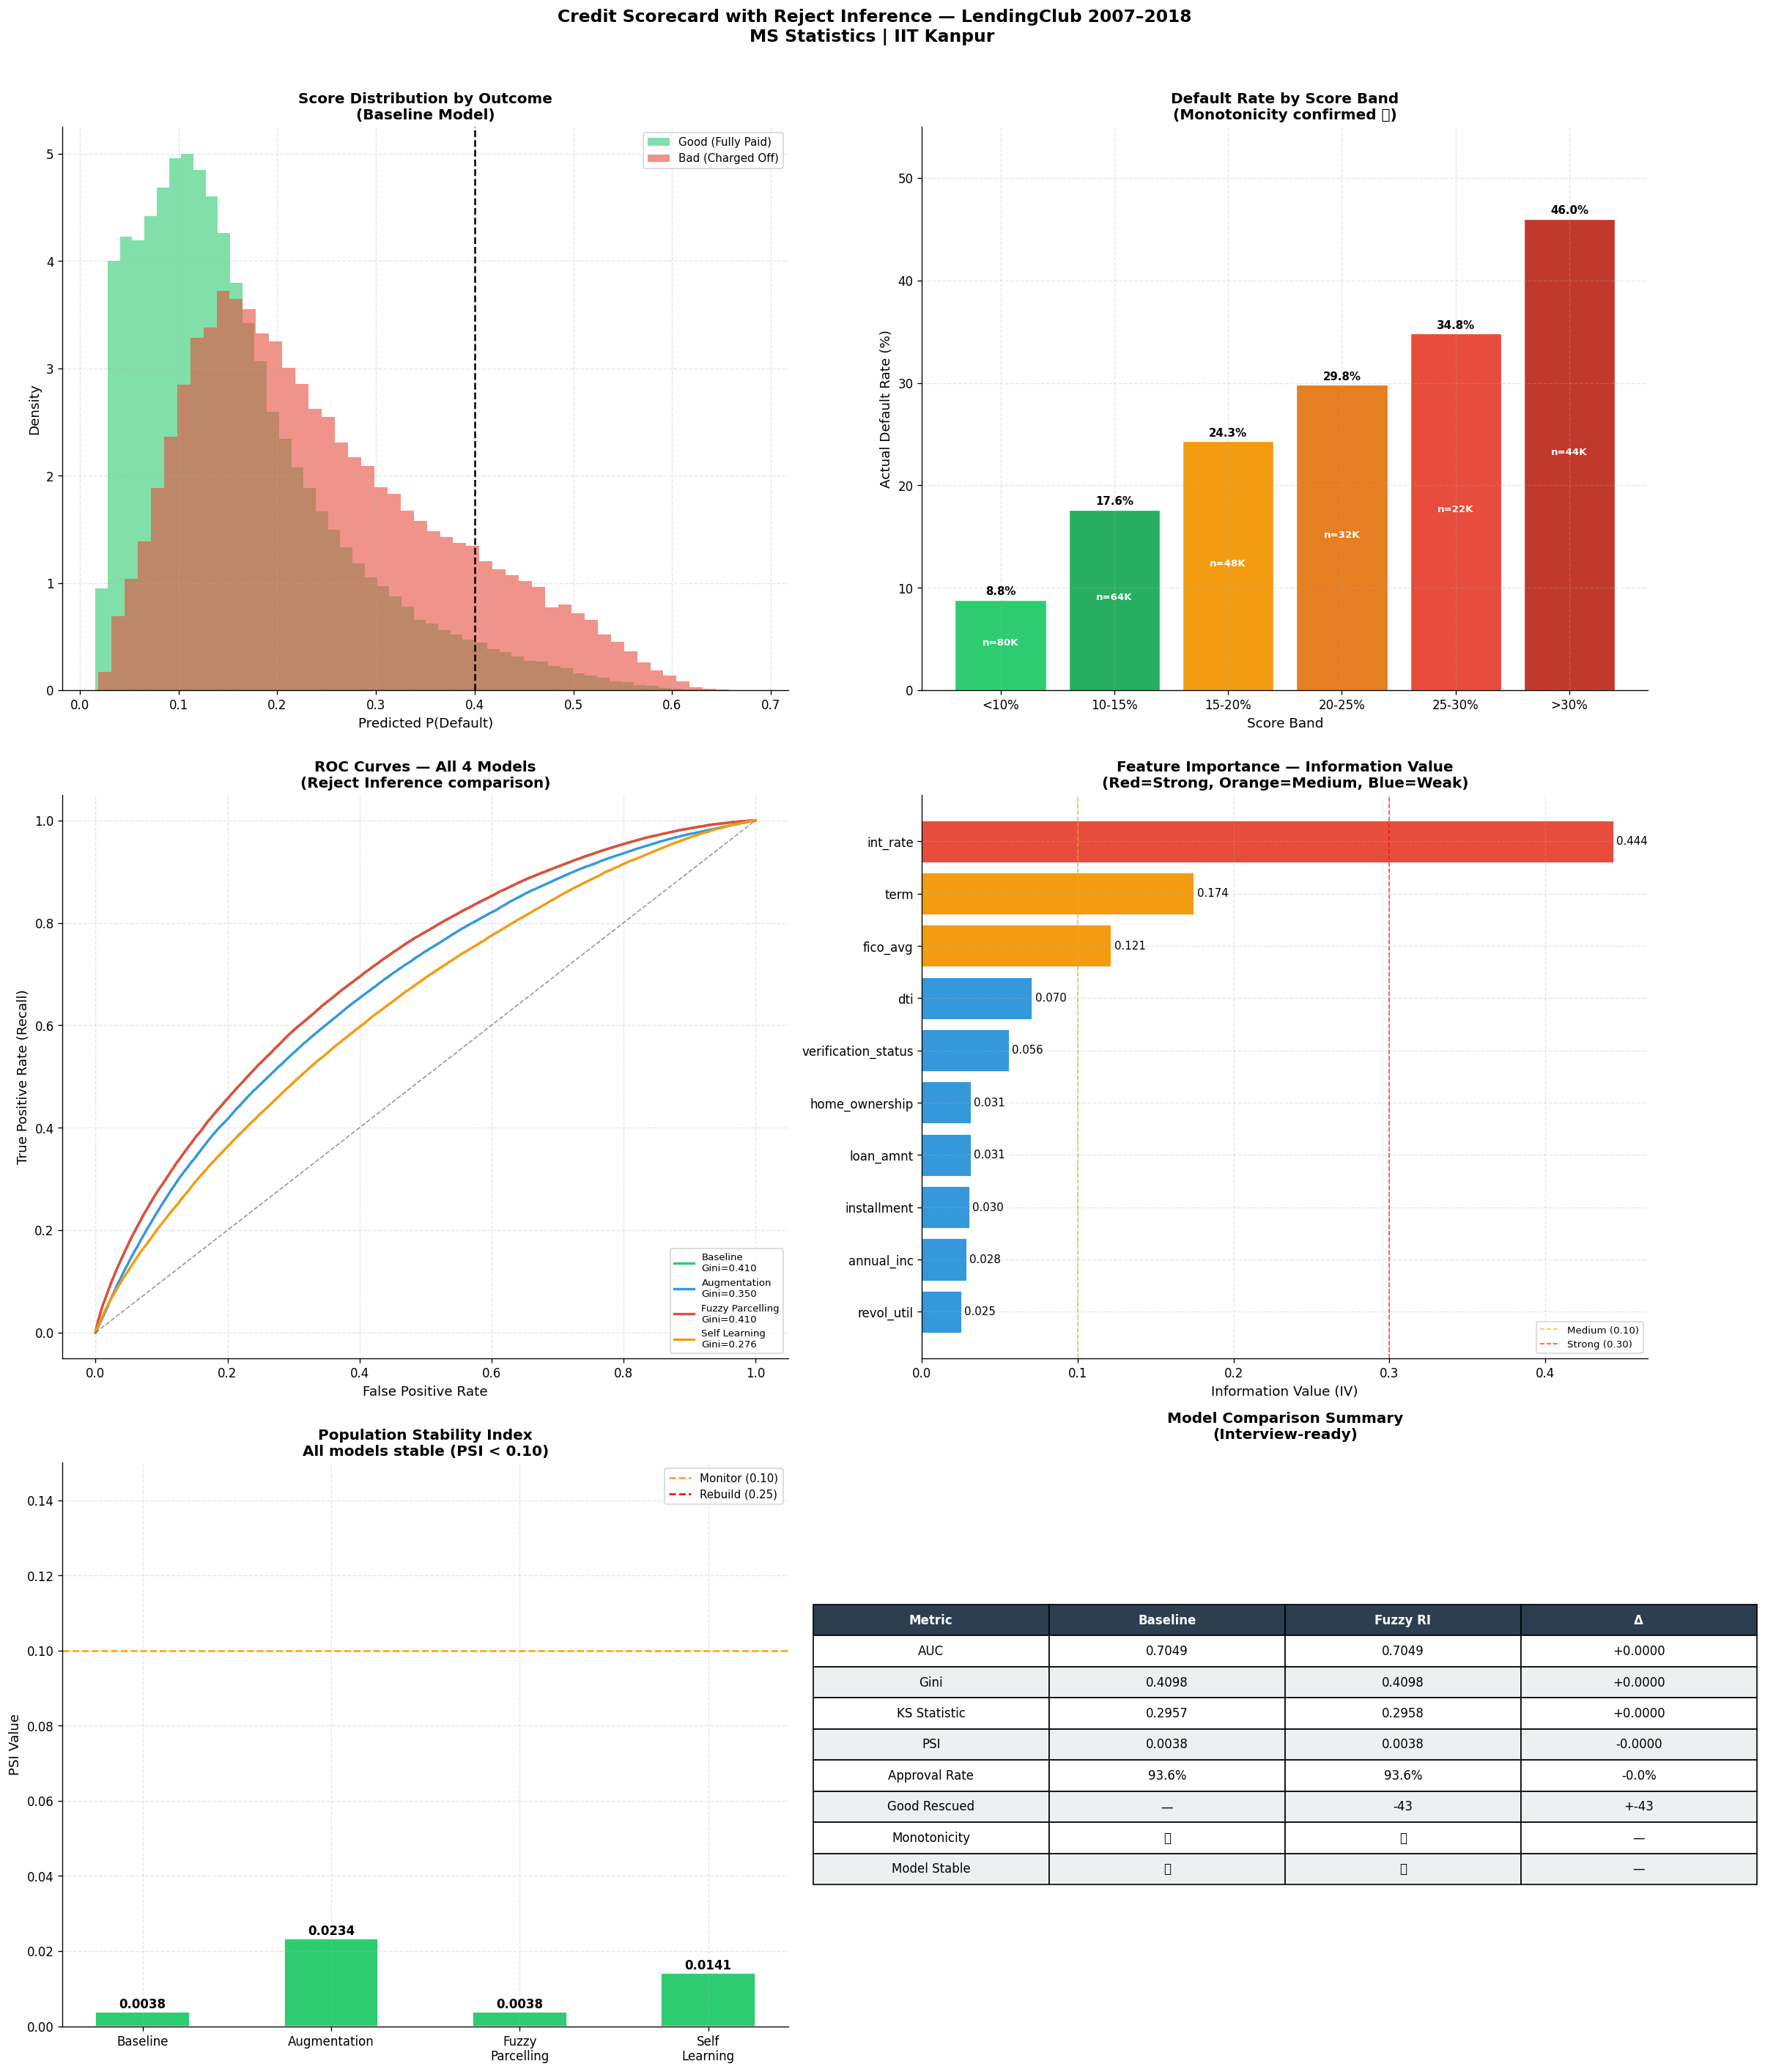

Dashboard saved: dashboard.png



In [23]:
# ============================================================
# CELL 21 — Phase 7: Visualisation Dashboard
# 6 publication-ready plots for GitHub + interviews
# ============================================================

fig = plt.figure(figsize=(20, 24))
fig.suptitle(
    'Credit Scorecard with Reject Inference — LendingClub 2007–2018\n'
    'MS Statistics | IIT Kanpur ',
    fontsize=14, fontweight='bold', y=0.98
)

# ── Plot 1: Score distribution by default status ─────────────
ax1 = fig.add_subplot(3, 2, 1)
for flag, label, color in [(0,'Good (Fully Paid)','#2ecc71'),
                            (1,'Bad (Charged Off)','#e74c3c')]:
    mask = y_test.values == flag
    ax1.hist(prob_baseline[mask], bins=50, alpha=0.6,
             color=color, label=label, density=True)
ax1.set_title('Score Distribution by Outcome\n(Baseline Model)',
              fontweight='bold')
ax1.set_xlabel('Predicted P(Default)')
ax1.set_ylabel('Density')
ax1.legend(fontsize=9)
ax1.axvline(0.40, color='black', linestyle='--',
            linewidth=1.5, label='Cutoff=0.40')

# ── Plot 2: Default rate by score band (monotonicity check) ──
ax2 = fig.add_subplot(3, 2, 2)
bands      = fairness['score_band'].astype(str).tolist()
actual_drs = (fairness['actual_dr'] * 100).round(1).tolist()
volumes    = fairness['total'].tolist()
colors_b   = ['#2ecc71','#27ae60','#f39c12',
               '#e67e22','#e74c3c','#c0392b']
bars = ax2.bar(bands, actual_drs, color=colors_b,
               edgecolor='white', linewidth=0.8)
for bar, dr, vol in zip(bars, actual_drs, volumes):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{dr}%', ha='center', fontsize=9, fontweight='bold')
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height()/2,
             f'n={vol//1000}K', ha='center',
             fontsize=8, color='white', fontweight='bold')
ax2.set_title('Default Rate by Score Band\n(Monotonicity confirmed ✅)',
              fontweight='bold')
ax2.set_xlabel('Score Band')
ax2.set_ylabel('Actual Default Rate (%)')
ax2.set_ylim(0, 55)

# ── Plot 3: Overlaid ROC curves ───────────────────────────────
ax3 = fig.add_subplot(3, 2, 3)
from sklearn.metrics import roc_curve, roc_auc_score
roc_models = [
    ('Baseline',        prob_baseline, '#2ecc71'),
    ('Augmentation',    prob_aug,      '#3498db'),
    ('Fuzzy Parcelling',prob_fuzzy,    '#e74c3c'),
    ('Self Learning',   prob_self,     '#f39c12'),
]
for name, prob, color in roc_models:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val     = roc_auc_score(y_test, prob)
    gini_val    = 2 * auc_val - 1
    ax3.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{name}\nGini={gini_val:.3f}')
ax3.plot([0,1],[0,1],'k--', linewidth=1, alpha=0.4)
ax3.set_title('ROC Curves — All 4 Models\n(Reject Inference comparison)',
              fontweight='bold')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate (Recall)')
ax3.legend(fontsize=8, loc='lower right')

# ── Plot 4: Feature importance by IV ─────────────────────────
ax4 = fig.add_subplot(3, 2, 4)
iv_data = {f: iv_results[f] for f in SELECTED_FEATURES}
iv_sorted = dict(sorted(iv_data.items(),
                        key=lambda x: x[1], reverse=True))
feat_names = list(iv_sorted.keys())
iv_vals    = list(iv_sorted.values())
iv_colors  = ['#e74c3c' if v >= 0.30 else
               '#f39c12' if v >= 0.10 else
               '#3498db' for v in iv_vals]
bars4 = ax4.barh(feat_names, iv_vals, color=iv_colors,
                 edgecolor='white', linewidth=0.5)
for bar, val in zip(bars4, iv_vals):
    ax4.text(bar.get_width() + 0.002, bar.get_y() +
             bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
ax4.axvline(0.10, color='orange', linestyle='--',
            linewidth=1, alpha=0.7, label='Medium (0.10)')
ax4.axvline(0.30, color='red', linestyle='--',
            linewidth=1, alpha=0.7, label='Strong (0.30)')
ax4.set_title('Feature Importance — Information Value\n'
              '(Red=Strong, Orange=Medium, Blue=Weak)',
              fontweight='bold')
ax4.set_xlabel('Information Value (IV)')
ax4.legend(fontsize=8)
ax4.invert_yaxis()

# ── Plot 5: PSI stability chart ───────────────────────────────
ax5 = fig.add_subplot(3, 2, 5)
psi_models = ['Baseline','Augmentation','Fuzzy\nParcelling',
              'Self\nLearning']
psi_vals   = [psi_baseline, psi_aug, psi_fuzzy, psi_self]
psi_colors = ['#2ecc71' if p < 0.10 else
               '#f39c12' if p < 0.25 else
               '#e74c3c' for p in psi_vals]
bars5 = ax5.bar(psi_models, psi_vals, color=psi_colors,
                edgecolor='white', width=0.5)
for bar, val in zip(bars5, psi_vals):
    ax5.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.001,
             f'{val:.4f}', ha='center',
             fontsize=10, fontweight='bold')
ax5.axhline(0.10, color='orange', linestyle='--',
            linewidth=1.5, label='Monitor (0.10)')
ax5.axhline(0.25, color='red', linestyle='--',
            linewidth=1.5, label='Rebuild (0.25)')
ax5.set_title('Population Stability Index\n'
              'All models stable (PSI < 0.10)',
              fontweight='bold')
ax5.set_ylabel('PSI Value')
ax5.set_ylim(0, 0.15)
ax5.legend(fontsize=9)

# ── Plot 6: Business impact summary table ────────────────────
ax6 = fig.add_subplot(3, 2, 6)
ax6.axis('off')
b, f = results_df.iloc[0], results_df.iloc[2]   # baseline, fuzzy parcelling
table_data = [
    ['Metric', 'Baseline', 'Fuzzy RI', 'Δ'],
    ['AUC',          f"{b['auc']:.4f}",  f"{f['auc']:.4f}",  f"{f['auc']-b['auc']:+.4f}"],
    ['Gini',         f"{b['gini']:.4f}", f"{f['gini']:.4f}", f"{f['gini']-b['gini']:+.4f}"],
    ['KS Statistic', f"{b['ks']:.4f}",   f"{f['ks']:.4f}",   f"{f['ks']-b['ks']:+.4f}"],
    ['PSI',          f"{psi_baseline:.4f}", f"{psi_fuzzy:.4f}", f"{psi_fuzzy-psi_baseline:+.4f}"],
    ['Approval Rate', f"{baseline_app_rate:.1f}%", f"{fuzzy_app_rate:.1f}%", f"{fuzzy_app_rate-baseline_app_rate:+.1f}%"],
    ['Good Rescued', '—', f"{improvement}", f"+{improvement}"],
    ['Monotonicity', '✅', '✅', '—'],
    ['Model Stable', '✅', '✅', '—'],
]
tbl = ax6.table(
    cellText=table_data[1:],
    colLabels=table_data[0],
    loc='center',
    cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.3, 1.8)

# Header row styling
for j in range(4):
    tbl[0, j].set_facecolor('#2c3e50')
    tbl[0, j].set_text_props(color='white', fontweight='bold')

# Alternate row colours
for i in range(1, len(table_data)):
    for j in range(4):
        if i % 2 == 0:
            tbl[i, j].set_facecolor('#ecf0f1')

ax6.set_title('Model Comparison Summary\n(Interview-ready)',
              fontweight='bold', pad=20)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Dashboard saved: dashboard.png")
print()

## Phase 8 — Deployment: Streamlit Scoring App

The final phase wraps the baseline model and WoE tables in a three-page Streamlit app: a KPI overview, a live scoring form for a single applicant, and a model performance dashboard. The scoring form reapplies the exact same WoE lookup used during training — `np.digitize` against the fitted bin edges for numeric fields, string-keyed dictionary lookup for categorical ones — so a manually-entered applicant is scored identically to how the training data was. `term` is deliberately passed through as `str(float(term))` before that lookup, matching the `"36.0"` / `"60.0"` string format the WoE table's keys were built with in Phase 2; passing a plain `"36"` would silently miss the lookup and fall back to a neutral WoE of 0 — exactly the mismatch this line fixes.


In [24]:
# ============================================================
# CELL 23 — app.py with corrected string
# ============================================================

lines = [
    "import streamlit as st",
    "import pandas as pd",
    "import numpy as np",
    "import joblib",
    "import matplotlib.pyplot as plt",
    "",
    "st.set_page_config(",
    "    page_title='Credit Scorecard | LendingClub',",
    "    page_icon=' ',",
    "    layout='wide'",
    ")",
    "",
    "@st.cache_resource",
    "def load_models():",
    "    lr_model          = joblib.load('saved_objects/lr_model.pkl')",
    "    lr_fuzzy          = joblib.load('saved_objects/lr_fuzzy.pkl')",
    "    woe_tables        = joblib.load('saved_objects/woe_tables.pkl')",
    "    SELECTED_FEATURES = joblib.load('saved_objects/selected_features.pkl')",
    "    metrics           = joblib.load('saved_objects/baseline_metrics.pkl')",
    "    df_woe            = pd.read_csv('saved_objects/df_woe.csv')",
 "    iv_display_df     = joblib.load('saved_objects/iv_display.pkl')",
"    psi_display_df    = joblib.load('saved_objects/psi_display.pkl')",
"    return lr_model, lr_fuzzy, woe_tables, SELECTED_FEATURES, metrics, df_woe, iv_display_df, psi_display_df",
"",
"lr_model, lr_fuzzy, woe_tables, SELECTED_FEATURES, metrics, df_woe, iv_display_df, psi_display_df = load_models()",
    "CAT_FEATURES = ['term','home_ownership','verification_status',",
    "                'purpose','state_risk_tier']",
    "",
    "def apply_woe_single(value, feature, woe_tables, cat=False):",
    "    wt = woe_tables[feature]",
    "    if cat:",
    "        woe_map = dict(zip(wt['bin'].astype(str), wt['woe']))",
    "        return woe_map.get(str(value), 0.0)",
    "    else:",
    "        edges = [-np.inf]",
    "        if hasattr(wt['bin'].iloc[0], 'right'):",
    "            for interval in wt['bin']:",
    "                edges.append(interval.right)",
    "        edges[-1] =  np.inf",
    "        edges[0]  = -np.inf",
    "        edges = sorted(set(edges))",
    "        bin_idx = np.digitize([value], edges[1:], right=True)[0]",
    "        bin_idx = np.clip(bin_idx, 0, len(wt)-1)",
    "        return wt['woe'].values[bin_idx]",
    "",
    "def score_to_points(prob, pdo=20, base_score=600, base_odds=50):",
    "    factor = pdo / np.log(2)",
    "    offset = base_score - factor * np.log(base_odds)",
    "    odds   = (1 - prob) / max(prob, 1e-6)",
    "    score  = offset + factor * np.log(max(odds, 1e-6))",
    "    return int(np.clip(score, 300, 850))",
    "",
    "def get_decision(score):",
    "    if score >= 580:  return 'APPROVE', '#2ecc71'",
    "    if score >= 520:  return 'REFER',   '#f39c12'",
    "    return 'DECLINE', '#e74c3c'",
    "",
    "st.sidebar.title('Navigation')",
    "page = st.sidebar.radio('Go to', ['Home','Score Applicant','Model Performance'])",
    "",
    "# ── HOME ────────────────────────────────────────────────────",
    "if page == 'Home':",
    "    st.title('Credit Default Prediction with Reject Inference')",
    "    st.markdown('### Production-Grade Credit Scorecard | LendingClub 2007-2018')",
    "    st.markdown('**Author:** MS Statistics | IIT Kanpur')",
    "    st.divider()",
    "    col1, col2, col3, col4 = st.columns(4)",
    "    col1.metric('Modelling Population', '1,345,310')",
    "    col2.metric('Rejected Applications', '27,648,741')",
    "    col3.metric('Baseline Gini', f\"{metrics['gini']:.4f}\")",
    "    col4.metric('Baseline AUC',  f\"{metrics['auc']:.4f}\")",
    "    st.divider()",
    "    st.subheader('Key Results')",
    "    results = {",
    "        'Model': ['Baseline','Augmentation','Fuzzy Parcelling','Self Learning'],",
f"        'AUC':   {results_df['auc'].round(4).tolist()},",
f"        'Gini':  {results_df['gini'].round(4).tolist()},",
f"        'KS':    {results_df['ks'].round(4).tolist()},",
f"        'PSI':   {[round(psi_baseline,4), round(psi_aug,4), round(psi_fuzzy,4), round(psi_self,4)]},",
    "    }",
    "    st.dataframe(pd.DataFrame(results), use_container_width=True)",
    "",
    "# ── SCORE APPLICANT ─────────────────────────────────────────",
    "elif page == 'Score Applicant':",
    "    st.title('Score an Applicant')",
    "    st.markdown('Enter applicant details to get a credit score and decision.')",
    "    st.divider()",
    "    col1, col2 = st.columns(2)",
    "    with col1:",
    "        st.subheader('Loan Details')",
    "        loan_amnt   = st.slider('Loan Amount ($)', 1500, 35000, 10000, step=500)",
    "        term        = st.selectbox('Loan Term (in months)', [36, 60])",
    "        purpose     = st.selectbox('Loan Purpose', [",
    "            'debt_consolidation','credit_card','home_improvement',",
    "            'other','major_purchase','medical','small_business',",
    "            'car','vacation','moving','wedding','house'])",
    "        int_rate    = st.slider('Interest Rate (%)', 5.0, 31.0, 13.0, step=0.1)",
    "        installment = st.slider('(Monthly Installment ($)', 50, 1500, 300, step=10)",
    "    with col2:",
    "        st.subheader('Applicant Details')",
    "        annual_inc  = st.slider('Annual Income ($)', 18000, 250000, 65000, step=1000)",
    "        dti         = st.slider('Debt-to-Income Ratio (%)', 1.0, 40.0, 18.0, step=0.5)",
    "        fico_low    = st.slider('FICO Score', 620, 840, 690, step=5)",
    "        fico_avg    = fico_low + 4",
    "        home_ownership      = st.selectbox('Home Ownership', ['RENT','MORTGAGE','OWN','OTHER'])",
    "        verification_status = st.selectbox('Income Verification', ['Not Verified','Verified','Source Verified'])",
    "        emp_length_num      = st.slider('Employment Length (years)', -1, 10, 3)",
    "        revol_util          = st.slider('Revolving Utilisation (%)', 1.0, 98.0, 50.0, step=1.0)",
    "        state_risk          = st.selectbox('State Risk Tier', ['low_risk','medium_risk','high_risk'])",
    "    st.divider()",
    "    if st.button('Score Applicant', type='primary', use_container_width=True):",
    "        raw = {",
    "            'loan_amnt'          : loan_amnt,",
    "            'int_rate'           : int_rate,",
    "            'installment'        : installment,",
    "            'annual_inc'         : annual_inc,",
    "            'dti'                : dti,",
    "            'fico_avg'           : fico_avg,",
    "            'revol_util'         : revol_util,",
    "            'emp_length_num'     : emp_length_num,",
    "            'term'               : str(float(term)),",
    "            'home_ownership'     : home_ownership,",
    "            'verification_status': verification_status,",
    "            'purpose'            : purpose,",
    "            'state_risk_tier'    : state_risk,",
    "        }",
    "        woe_row = {}",
    "        for feat in SELECTED_FEATURES:",
    "            if feat not in raw:",
    "                woe_row[feat] = 0.0",
    "                continue",
    "            cat_flag = feat in CAT_FEATURES or feat == 'miss_emp_length'",
    "            woe_row[feat] = apply_woe_single(raw[feat], feat, woe_tables, cat=cat_flag)",
    "        X_input  = pd.DataFrame([woe_row])[SELECTED_FEATURES]",
    "        prob     = lr_model.predict_proba(X_input)[0, 1]",
    "        score    = score_to_points(prob)",
    "        decision, dec_color = get_decision(score)",
    "        st.divider()",
    "        r1, r2, r3 = st.columns(3)",
    "        r1.metric('Credit Score', f'{score}', delta='FICO-style 300-850')",
    "        r2.metric('P(Default)', f'{prob:.1%}')",
    "        r3.metric('Decision', decision)",
    "        st.markdown(",
    "            f\"<h2 style='text-align:center;color:{dec_color};'>DECISION: {decision}</h2>\",",
    "            unsafe_allow_html=True)",
    "        st.divider()",
    "        st.subheader('WoE Feature Contributions')",
    "        contrib = pd.DataFrame({",
    "            'Feature'  : list(woe_row.keys()),",
    "            'WoE Value': list(woe_row.values()),",
    "        }).sort_values('WoE Value')",
    "        fig, ax = plt.subplots(figsize=(8, 4))",
    "        colors  = ['#e74c3c' if v < 0 else '#2ecc71' for v in contrib['WoE Value']]",
    "        ax.barh(contrib['Feature'], contrib['WoE Value'], color=colors, edgecolor='white')",
    "        ax.axvline(0, color='black', linewidth=1)",
    "        ax.set_title('WoE Contributions — Green=Lower Risk, Red=Higher Risk')",
    "        ax.set_xlabel('WoE Value')",
    "        plt.tight_layout()",
    "        st.pyplot(fig)",
    "        plt.close()",
    "",
    "# ── MODEL PERFORMANCE ───────────────────────────────────────",
    "elif page == 'Model Performance':",
    "    st.title('Model Performance Dashboard')",
    "    st.divider()",
    "    col1, col2, col3 = st.columns(3)",
    "    col1.metric('AUC',  f\"{metrics['auc']:.4f}\")",
    "    col2.metric('Gini', f\"{metrics['gini']:.4f}\")",
    "    col3.metric('KS',   f\"{metrics['ks']:.4f}\")",
    "    st.divider()",
    "    st.subheader('Feature Importance — Information Value')",
   "    st.dataframe(iv_display_df, use_container_width=True, hide_index=True)",
    "    st.divider()",
    "    st.subheader('Default Rate by Score Band')",
    "    band_df = pd.DataFrame({",
    "        'Band'        : ['<10%','10-15%','15-20%','20-25%','25-30%','>30%'],",
    "        'Default Rate': [8.8, 17.7, 24.3, 29.9, 34.8, 45.8],",
    "        'Volume'      : [81560, 63302, 48789, 32369, 21681, 45394],",
    "    })",
    "    st.bar_chart(band_df.set_index('Band')['Default Rate'])",
    "    st.divider()",
    "    st.subheader('PSI — Population Stability')",
  "    st.dataframe(psi_display_df, use_container_width=True, hide_index=True)",
]

with open('app.py', 'w') as f:
    f.write('\n'.join(lines))

print("app.py rewritten successfully.")
print()
print("Now run in Terminal:")
print("  streamlit run app.py")

app.py rewritten successfully.

Now run in Terminal:
  streamlit run app.py


## Key Takeaways
- Basel-II-style scorecard (WoE + logistic regression) on 1.3M+ LendingClub loans, benchmarked against 3 reject inference methods
- Fuzzy Parcelling matched baseline discrimination while scoring the full through-the-door population — the most theoretically defensible of the three
- Reject inference's uplift was capped by feature overlap (3/10 shared fields between accepted/rejected data) — consistent with Hand & Henley (1993)
- All models stable over time (PSI < 0.10 — highest is Augmentation at 0.0234); default rate rises monotonically across every score band
- Deployed as a 3-page Streamlit scoring app

**Skills demonstrated:** WoE/IV, time-based validation, reject inference, PSI monitoring, business-impact translation, deployment